# Analyzing Domain Architecture Contributions for predicted Fusion Proteins (CCLE)

Here, I will take the CCLE DANSy analysis and determine if there is an over-representation of specific domain n-grams that are either contributed or lost during fusion protein formation.

In [1]:
import dansy
import numpy as np
import pandas as pd
import fusionClasses as fc
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import itertools
import scipy.stats as stats
from collections import Counter
from tqdm import tqdm
import EnrichementAnalysis
from matplotlib.ticker import ScalarFormatter

In [2]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 200


In [3]:
# For a handful of genes they lack an ensembl ID so will try to convert them, but otherwise will drop them
gene_conv = pd.read_csv('ENSEMBL_Gene_Conversion.csv')
gene_conv = gene_conv.filter(['Gene stable ID', 'Gene name'], axis = 1).drop_duplicates()
conv_dict = dict(zip(gene_conv['Gene name'], gene_conv['Gene stable ID']))

In [4]:
def fix_ensembl(row, gene_pos, cnv = conv_dict):
    ensembl_name = f'gene{gene_pos}_ensembl'
    symbol_name =f'gene{gene_pos}_symbol'
    val = row[ensembl_name]
    gene_name = row[symbol_name]
    if val == '':
        
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    elif val in cnv.values():
        new_val = val
    else: # Double-check any that are not the current ENSEMBL ID
        if gene_name in cnv.keys():
            new_val = cnv[gene_name]
        else:
            new_val = None
    
    return new_val

In [5]:
# Reloading some of the raw data

ccle_fusions = pd.read_csv('CCLE_OmicsFusionFilteredSupplementary.csv', index_col=0)
ccle_model_info = pd.read_csv('CCLE_Model.csv')

# A little bit of pre-filtering to remove any of the out of frame fusions because predicting their domain architecture is not accurate
ccle_fusions = ccle_fusions[ccle_fusions['reading_frame'] != 'out-of-frame']

# Additionally removing low confidence fusions and any with FFPM value < 0.1 a general cutoff for fusion artifacts
ccle_fusions = ccle_fusions[ccle_fusions['confidence'] == 'high']
ccle_fusions = ccle_fusions[ccle_fusions['FFPM'] >= 0.1]

# Now let's create a new dataframe that has only relevant information for the time being that can then be passed on to create a fusion gene collection object.
dataOI = ccle_fusions.filter(['ModelID','CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)','strand1(gene/fusion)', 'strand2(gene/fusion)','breakpoint1', 'breakpoint2']).copy()
dataOI[['gene1_symbol','gene1_ensembl'] ]= dataOI['gene1(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI[['gene2_symbol','gene2_ensembl']] = dataOI['gene2(ENS ID)'].str.split(r'[()]', expand=True, n=1)
dataOI['gene1_symbol']=dataOI['gene1_symbol'].str.strip()
dataOI['gene2_symbol']=dataOI['gene2_symbol'].str.strip()
dataOI['gene1_ensembl']=dataOI['gene1_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['gene2_ensembl']=dataOI['gene2_ensembl'].str.split('.', n=1, expand=True)[0]
dataOI['strand1'] = dataOI['strand1(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI['strand2'] = dataOI['strand2(gene/fusion)'].apply(lambda x: x.split('/')[1])
dataOI[['gene1_chr','gene1_pos']] = dataOI['breakpoint1'].str.split(':', n=1, expand=True)
dataOI[['gene2_chr','gene2_pos']] = dataOI['breakpoint2'].str.split(':', n=1, expand=True)
dataOI['gene1_pos']=dataOI['gene1_pos'].astype(int)
dataOI['gene2_pos']=dataOI['gene2_pos'].astype(int)

# Mapping missing gene ensembl names
dataOI['gene1_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 1) , axis=1)
dataOI['gene2_ensembl']=dataOI.apply(lambda x: fix_ensembl(x, 2) , axis=1)
dataOI.dropna(subset=['gene1_ensembl', 'gene2_ensembl'],inplace=True)
dataOI['fusion_protein_name'] = dataOI.gene1_symbol.str.cat(dataOI.gene2_symbol, sep = '--')

In [6]:
# DANSy object of the full natural proteome
ref_df = dansy.import_proteome_files(ref_file_dir='data/Current_Human_Proteome',
                                       ref_file_suffix='2026_0108.csv')
proteome_net = dansy.dansy(ref=ref_df, n=15)
# Now with all the pre-filtering done let's run the DANSy fusion analysis
mappings = {'h_gene':'gene1_ensembl', 't_gene':'gene2_ensembl', 'h_chr':'gene1_chr', 't_chr':'gene2_chr', 'h_strand':'strand1', 't_strand':'strand2', 'name':'CanonicalFusionName', 'h_pos':'gene1_pos', 't_pos':'gene2_pos'}


Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [7]:
ccle_fc = fc.fusionCollection(dataOI, mappings, add_cols=['ModelID', 'gene1_symbol','gene2_symbol', 'fusion_protein_name'])
ccle_fc.perform_dansy_analysis(dansy_obj=proteome_net)
dansy_sum = ccle_fc.summarize_dansy_results()

100%|██████████| 3153/3153 [00:30<00:00, 103.56it/s]


There were 1456 fusion domain architectures previously found in the proteome.


# Performing the enrichment analysis

A network visualization of the results is not super informative with ~80% of proteins involved in the fusions consistently providing portions without domain annotations to the final fusion product. So here I will look at the actual protein domain architectures to see which domains/domain n-grams are consistently being shuffled or lost.

In [ ]:
# This starts off very similar to what was done above but this time focusing on the parent protein domain architectures
ids_4_analysis = []
for i,f in ccle_fc.fusion_list.items():
    if 't_contribution' in f.__dict__ and 'h_contribution' in f.__dict__:
        # Now check if there are domain annotations for both parent proteins otherwise won't add
        h_arch = proteome_net.retrieve_protein_info(prot = f.h_uniprot)['Interpro Domain Architecture IDs'].values[0]
        t_arch = proteome_net.retrieve_protein_info(prot = f.t_uniprot)['Interpro Domain Architecture IDs'].values[0]
        if h_arch != '' or t_arch != '': # Ignore the fusions that consist of only proteins with no domain annotations.
            ids_4_analysis.append(i)


In [ ]:
# Now for determining the overrepresentation, I will be taking the list of unique fusion n-grams and finding how many fusions have a specific n-gram and then designating whether the 5' gene or 3' gene also has that part of the n-gram.

# Getting all the unique n-grams from the fusions
all_ngrams = []
ngram_dict = {}
for fid in ids_4_analysis:
    f = ccle_fc.get_fusion(fid)
    all_ngrams.append(f.ngrams)
    for ngram in f.ngrams:
        if ngram in ngram_dict:
            ngram_dict[ngram].append(fid)
        else:
            ngram_dict[ngram] = [fid]

all_ngrams = list(itertools.chain.from_iterable(all_ngrams))
full_proteome_ngrams = set(proteome_net.ngrams).union(proteome_net.collapsed_ngrams)
ngrams4analysis = set(all_ngrams).intersection(full_proteome_ngrams)

# Now dropping any n-grams that only appeared once cause that is going to cause extremes that are not necessarily useful for looking in overrepresentation analysis.
multingrams = [k for k, v in Counter(all_ngrams).items() if v > 1]
ngrams4analysis = ngrams4analysis.intersection(multingrams)

print(f'There will be {len(ngrams4analysis)} domain n-grams that will be analyzed.\nOriginal total: {len(set(all_ngrams))}')

There will be 6942 domain n-grams that will be analyzed.
Original total: 23381


In [ ]:
fusion_info_OI = dansy_sum[dansy_sum['id'].isin(ids_4_analysis)].copy()

In [ ]:
# Starting to build up pieces of the contigency tables
M = len(ids_4_analysis)
N = {k:0 for k in ngrams4analysis} # The fusions where the 5' gene has the domain n-gram
n = {k:0 for k in ngrams4analysis} # The fusions where the ngram is in the domain architecture
kin_check = [] # To verify
fv_prots = list(fusion_info_OI.h_uniprot)

for ngram in tqdm(ngrams4analysis):
    id_list = ngram_dict[ngram]
    n[ngram] = len(id_list)
    try:
        x1 = proteome_net.retrieve_protein_info(ngram=ngram)
        N[ngram] = sum(fusion_info_OI['h_uniprot'].isin(x1['UniProt ID']))
    except KeyError:
        x1 = proteome_net.retrieve_protein_info(prot = set(fv_prots))
        y = dict(zip(x1['UniProt ID'],x1['Interpro Domain Architecture IDs']))
        N[ngram] = sum([ngram in y[i] for i in fv_prots])

# Now for the tables:
ngram_tables = {}
for ngram in ngrams4analysis:
    x = 0
    for fid in ids_4_analysis:
        f = ccle_fc.get_fusion(fid)
        if ngram in f.h_contribution:
            x += 1
    a = x
    b = n[ngram] - x
    c = N[ngram] - x
    d = M - (n[ngram] + N[ngram]) + x
    table = [[a,b], [c,d]]
    ngram_tables[ngram] = table

100%|██████████| 6942/6942 [00:06<00:00, 1084.00it/s]


In [ ]:
fres = {}
for ngram,table in ngram_tables.items():
    res = stats.fisher_exact(table, alternative = 'greater')
    fres[ngram] = res.pvalue

In [ ]:
thr_prots = list(fusion_info_OI.t_uniprot)

for ngram in tqdm(ngrams4analysis):
    id_list = ngram_dict[ngram]
    n[ngram] = len(id_list)
    try:
        x1 = proteome_net.retrieve_protein_info(ngram=ngram)
        N[ngram] = sum(fusion_info_OI['t_uniprot'].isin(x1['UniProt ID']))
    except KeyError:
        x1 = proteome_net.retrieve_protein_info(prot = set(thr_prots))
        y = dict(zip(x1['UniProt ID'],x1['Interpro Domain Architecture IDs']))
        N[ngram] = sum([ngram in y[i] for i in thr_prots])

# Now for the tables:
ngram_tables = {}
for ngram in ngrams4analysis:
    x = 0
    for fid in ids_4_analysis:
        f = ccle_fc.get_fusion(fid)
        if ngram in f.t_contribution:
            x += 1
    a = x
    b = n[ngram] - x
    c = N[ngram] - x
    d = M - (n[ngram] + N[ngram]) + x
    table = [[a,b], [c,d]]
    ngram_tables[ngram] = table

fres_thr = {}
for ngram,table in ngram_tables.items():
    res = stats.fisher_exact(table,alternative='greater')
    fres_thr[ngram] = res.pvalue

100%|██████████| 6942/6942 [00:06<00:00, 1077.26it/s]


In [ ]:
temp = pd.DataFrame.from_dict(fres, orient='index')
temp.reset_index(inplace=True)
temp.rename(columns={'index':'n-gram', 0:'Five'}, inplace=True)

temp2 = pd.DataFrame.from_dict(fres_thr, orient='index')
temp2.reset_index(inplace=True)
temp2.rename(columns={'index':'n-gram', 0:'Three'}, inplace=True)

res_df = pd.merge(temp, temp2)

In [ ]:
res_df['Five_q'] = stats.false_discovery_control(res_df.Five,method='bh')
res_df['Three_q'] = stats.false_discovery_control(res_df.Three,method='bh')

In [ ]:
res_df

,n-gram,Five,Three,Five_q,Three_q
0,IPR003598|IPR003598|IPR003598|IPR003598|IPR003...,1.000000e+00,7.701480e-08,1.000000e+00,1.142630e-07
1,IPR006211|IPR000494|IPR003961,1.540296e-07,1.000000e+00,6.797670e-07,1.000000e+00
2,IPR003598|IPR003598|IPR003598|IPR003598|IPR003...,1.000000e+00,7.701480e-08,1.000000e+00,1.142630e-07
3,IPR000742|IPR000742|IPR009254|IPR010307|IPR001791,1.132631e-03,1.585504e-03,2.996465e-03,1.851399e-03
4,IPR003593|IPR020587,1.000000e+00,2.567160e-08,1.000000e+00,4.348762e-08
...,...,...,...,...,...
6937,IPR003410|IPR003410|IPR000436|IPR011641|IPR011...,8.599469e-48,1.000000e+00,2.630495e-46,1.000000e+00
6938,IPR000998|IPR000998|IPR055163|IPR000719,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
6939,IPR056609,1.000000e+00,2.567160e-08,1.000000e+00,4.348762e-08
6940,IPR003598|IPR003599|IPR003598|IPR003598|IPR003598,1.540296e-07,1.000000e+00,6.797670e-07,1.000000e+00


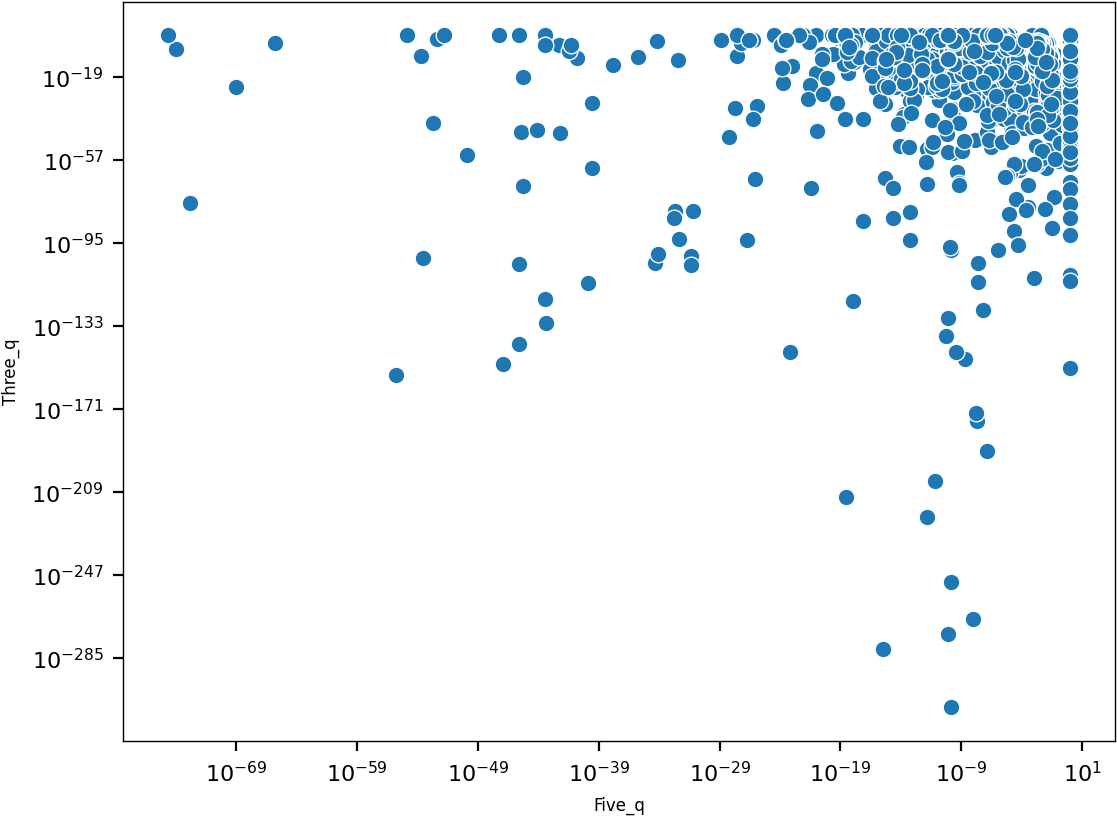

In [ ]:
sns.scatterplot(res_df, x = 'Five_q', y = 'Three_q')
plt.xscale('log')
plt.yscale('log')

I don't trust results with that significant of p-values, which suggests to me that I did something wrong with the question I was asking. I can double check this by creating a null distribution of randomly chosen genes and breakpoints, but that will be a second check. Instead I will shift gears every so slightly by trying the same Fisher's exact test strategy, but this time categorizing the fusions based on their impact where I will compare those with the novel architectures (Reinforcement/Bridges) to the others. This is a more fair test IMO since it compares the breakpoints to understand if there are domain n-grams that are enriched in creating new functions or not.

In [ ]:
# We don't have to get the n-gram list again nor the IDs since those are the same as what we would be analyzing anyway
M = len(ids_4_analysis)
N = sum(fusion_info_OI.dansy_impact.isin(['Bridges','Reinforcement']))
br_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for fid in ids_4_analysis:
        f = ccle_fc.get_fusion(fid)
        if ngram in f.domain_architecture:
            n += 1
            if f.dansy_impact in ['Bridges','Reinforcement']:
                x += 1
    if ngram == 'IPR000719':
        print(f'Kinase: N:{N}, M:{M}, n:{n}, x:{x}')
    elif ngram == 'IPR001849':
        print(f'FN3? N:{N}, M:{M}, n:{n}, x:{x}')
    br_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)


Kinase: N:1284, M:8827, n:279, x:122
FN3? N:1284, M:8827, n:174, x:70


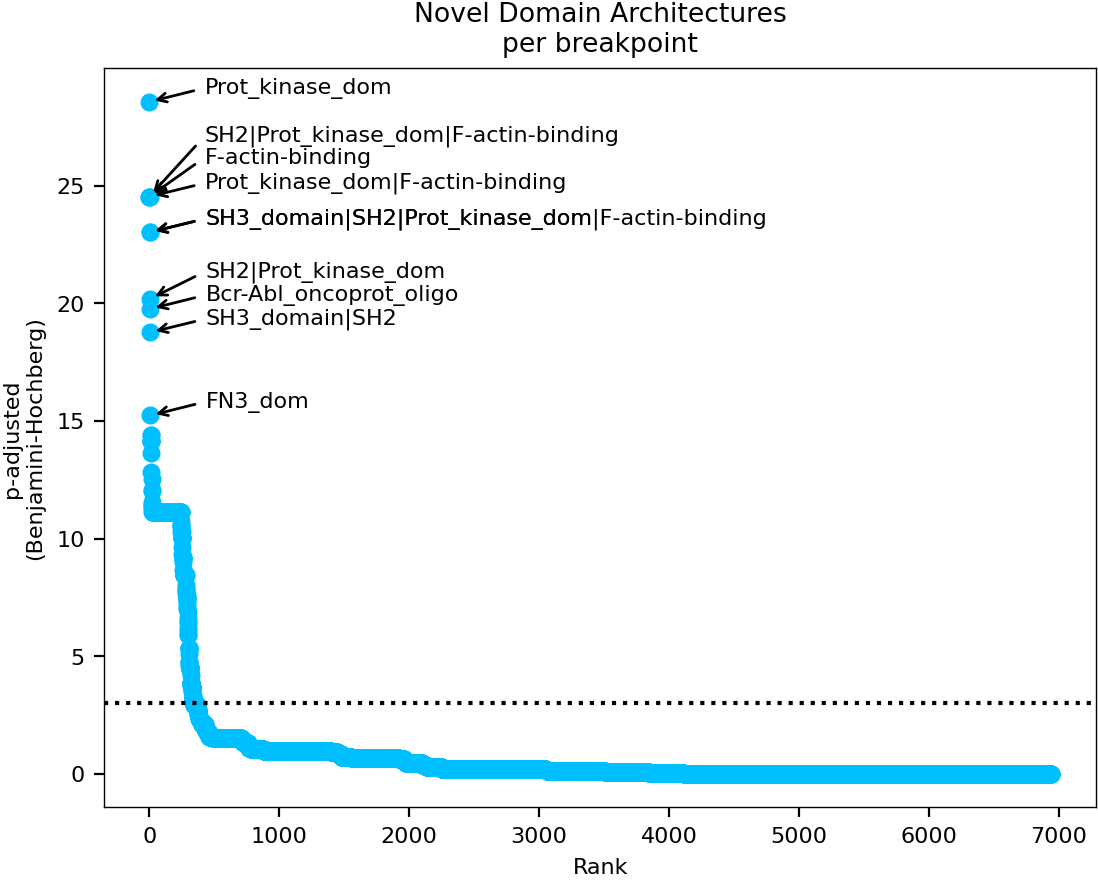

In [ ]:
xoffset = 20
yoffset = [3,20,12,3,3,3,8,3,3,3]
x = pd.DataFrame.from_dict(br_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1*np.log10(stats.false_discovery_control(x[0], method='bh'))


ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None, color='deepskyblue')

# For the top 10 ngrams will label with their legible n-gram name
for i,ngram_info in x[0:10].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )

plt.axhline(3, ls = ':', color = 'k')
plt.title('Novel Domain Architectures\nper breakpoint')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
fusion_info_OI.columns

Index(['name', 'h_gene', 't_gene', 'h_uniprot', 't_uniprot', 'h_chr', 't_chr',
       'h_pos', 't_pos', 'h_strand', 't_strand', 'id', 'domain_architecture',
       'ModelID', 'gene1_symbol', 'gene2_symbol', 'fusion_protein_name',
       'dansy_impact'],
      dtype='object')

In [ ]:
# SInce it is pretty obvious there are several domain architectures from BCR-ABL let's check which architectures have the most breakpoints
quick_check = fusion_info_OI.groupby(['dansy_impact','fusion_protein_name','domain_architecture'])
sum_quick_check = []
for g in quick_check.groups:
    temp = {}
    temp['DANSy']= g[0]
    temp['Name']= g[1]
    temp['Domain_arch']= g[2]
    temp['n'] = len(quick_check.get_group(g))
    temp = pd.Series(temp)
    sum_quick_check.append(temp)
sum_quick_check = pd.concat(sum_quick_check, axis = 1).T
sum_quick_check['n']=sum_quick_check['n'].astype(int)
sum_quick_check.sort_values('n', ascending=False)

,DANSy,Name,Domain_arch,n
4329,No Change,SLC7A1--SLC7A1,IPR029485,27
2998,No Change,EWSR1--FLI1,IPR000418,25
1796,No Annotation,RPS6KB1--VMP1,,24
2338,No Change,ABL1--BCR,IPR000198,21
4991,Reinforcement,BCR--ABL1,IPR015123|IPR000219|IPR001849|IPR001452|IPR000...,20
...,...,...,...,...
2398,No Change,AKAP6--COCH,IPR004043|IPR002035|IPR002035,1
2396,No Change,AKAP13--MYL10,IPR002048|IPR002048,1
2395,No Change,AKAP13--MYL10,IPR002048,1
2394,No Change,AK4--DNAJC6,IPR000387|IPR014020|IPR001623,1


One small caveat of the above plot is that we may be getting skewed because of having several breakpoints that create the same fusion domain architecture. So one of the things we can look at is what about the domain architectures that are unique to a gene fusion pair within a specific cell line. We can control the effects from multiple breakpoints within the same cell line that are creating the same protein a little better in that case.

In [ ]:
fusion_group = fusion_info_OI.groupby(['fusion_protein_name','domain_architecture','dansy_impact','ModelID'])

In [ ]:
{g:len(fusion_group.get_group(g)) for g in fusion_group.groups if len(fusion_group.get_group(g)) > 10}

{('KANSL1--GAST', 'IPR001651', 'No Change', 'ACH-000466'): 12}

In [ ]:
# This is to just verify that there is a reduction of some point and that this is worth doing.
cnt = 0
for g in fusion_group.groups:
    l = len(fusion_group.get_group(g))
    if l > 1:
        cnt += 1
print(f'There were {cnt} fusion proteins with multiple breakpoints')

There were 1222 fusion proteins with multiple breakpoints


In [ ]:
# Now let's take each of these groups and do the enrichment analysis to prevent any strange issues due to multiple breakpoints (Note: this is still probably half biased because of what are successful ccell lines.)
M = fusion_group.ngroups
N = sum([g[2] in ['Bridges','Reinforcement'] for g in fusion_group.groups])
br_uni_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for g in fusion_group.groups:
        if ngram in g[1]:
            n += 1
            if g[2] in ['Bridges','Reinforcement']:
                x += 1
    br_uni_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)


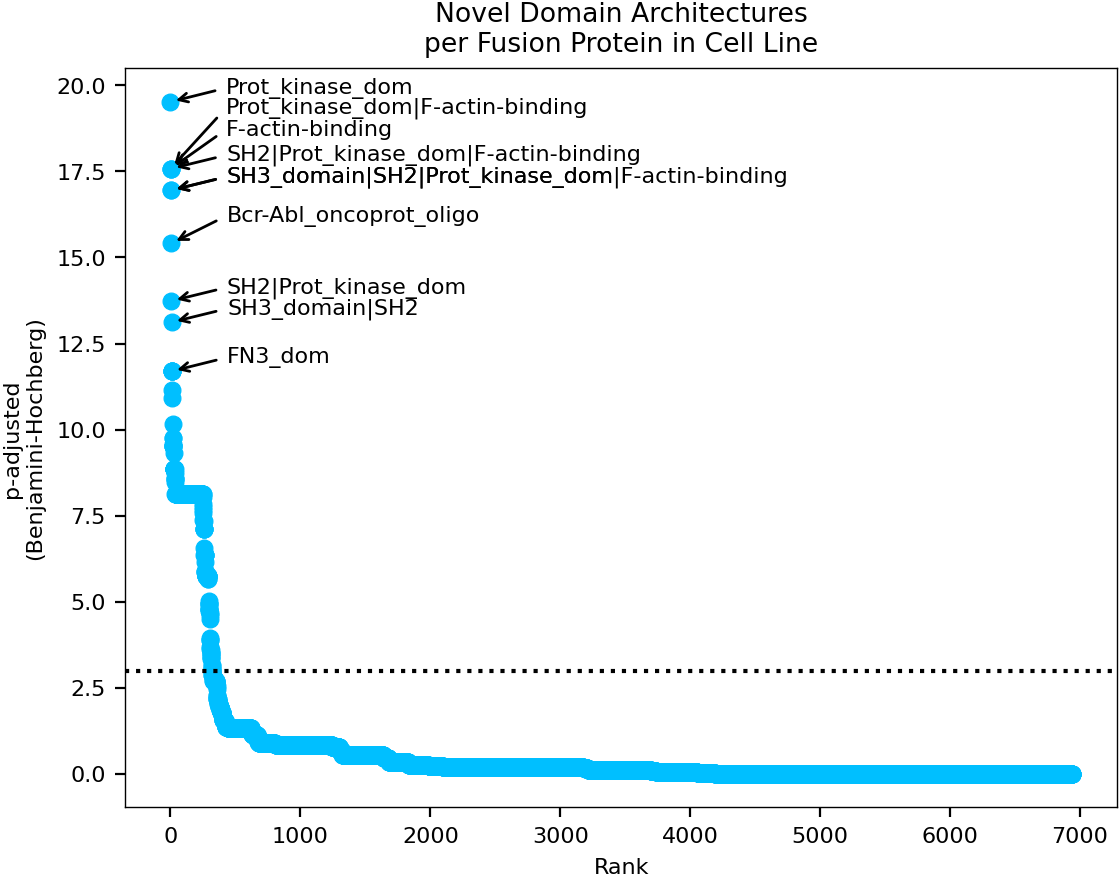

In [ ]:
x = pd.DataFrame.from_dict(br_uni_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1 * np.log10(stats.false_discovery_control(x[0], method='bh'))

ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')


# For the top 10 ngrams will label with their legible n-gram name
for i,ngram_info in x[0:10].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )
plt.title('Novel Domain Architectures\nper Fusion Protein in Cell Line')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
# Now let's look at individual fusion protein domain architectures instead of a per cell line
fusion_info_OI['fusion_protein_name'] = fusion_info_OI['gene1_symbol'].str.cat(fusion_info_OI['gene2_symbol'], sep='--')
fusion_group_uni = fusion_info_OI.groupby(['fusion_protein_name','domain_architecture','dansy_impact'])
M = fusion_group_uni.ngroups
N = sum([g[2] in ['Bridges','Reinforcement'] for g in fusion_group_uni.groups])
uni_dom_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for g in fusion_group_uni.groups:
        if ngram in g[1]:
            n += 1
            if g[2] in ['Bridges','Reinforcement']:
                x += 1
    uni_dom_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)


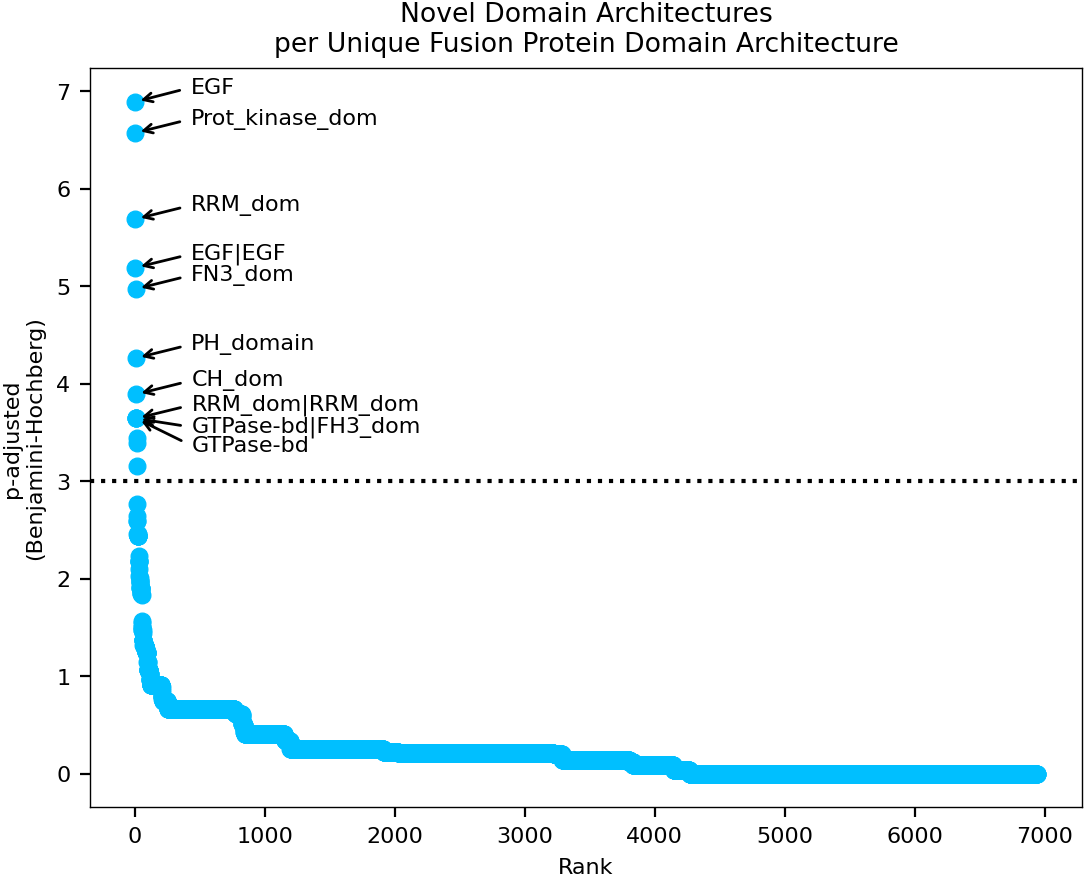

In [ ]:

x = pd.DataFrame.from_dict(uni_dom_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1 * np.log10(stats.false_discovery_control(x[0], method='bh'))
yoffset = [3,3,3,3,3,3,3,3,-5,-12]
ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')


# For the top 10 ngrams will label with their legible n-gram name
for i,ngram_info in x[0:10].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )
plt.title('Novel Domain Architectures\nper Unique Fusion Protein Domain Architecture')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

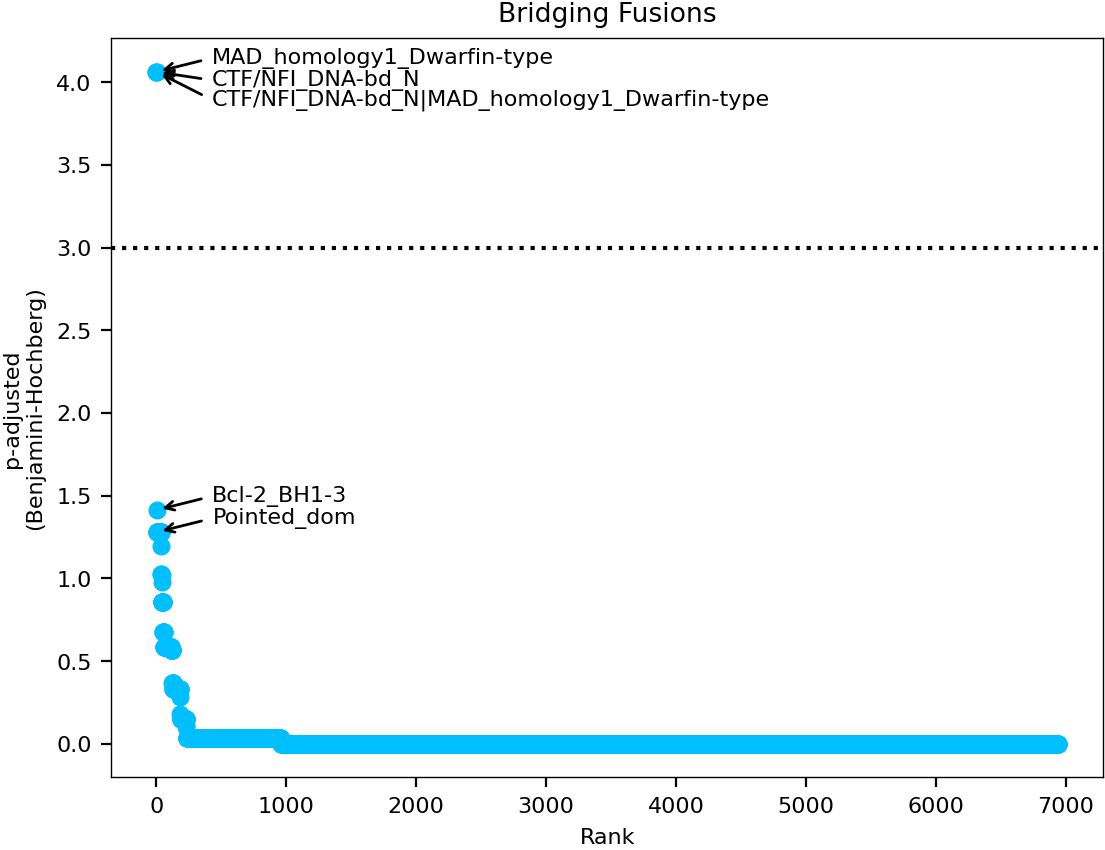

In [ ]:
# Let's get a little more granular and look at the specific categories now
M = fusion_group_uni.ngroups
N = sum([g[2] in ['Bridges'] for g in fusion_group_uni.groups])
br_uni_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for g in fusion_group_uni.groups:
        if ngram in g[1]:
            n += 1
            if g[2] in ['Bridges']:
                x += 1
    br_uni_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)
yoffset = [3,-5,-12,3,3]
x = pd.DataFrame.from_dict(br_uni_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1 * np.log10(stats.false_discovery_control(x[0], method='bh'))

ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')


# For the top 10 ngrams will label with their legible n-gram name
for i,ngram_info in x[0:5].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )
plt.title('Bridging Fusions')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
# Let's get a little more granular and look at the specific categories now
M = fusion_group_uni.ngroups
N = sum([g[2] in ['Reinforcement'] for g in fusion_group_uni.groups])
br_uni_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for g in fusion_group_uni.groups:
        if ngram in g[1]:
            n += 1
            if g[2] in ['Reinforcement']:
                x += 1
    br_uni_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)


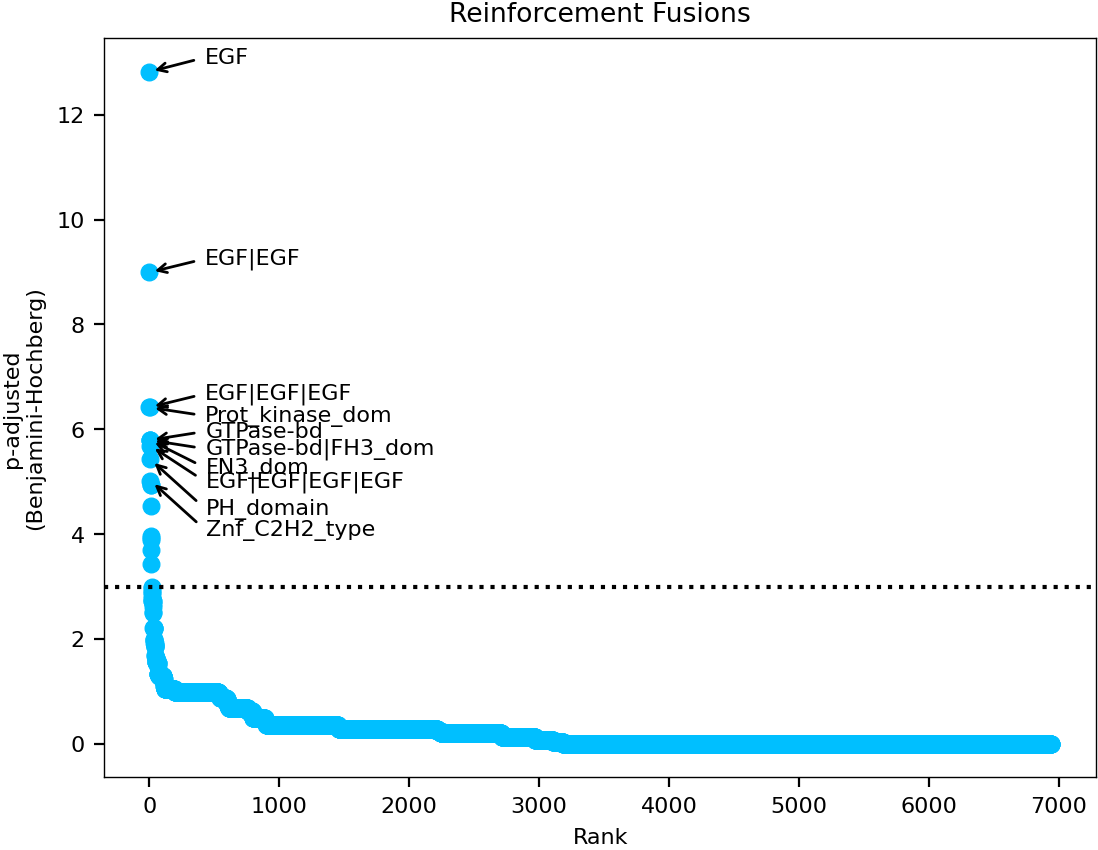

In [ ]:

yoffset = [3,3,3,-5,1,-5,-12,-15,-20,-20]
x = pd.DataFrame.from_dict(br_uni_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1 * np.log10(stats.false_discovery_control(x[0], method='bh'))

ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')


# For the top 10 ngrams will label with their legible n-gram name
for i,ngram_info in x[0:10].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )
plt.title('Reinforcement Fusions')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
# Let's do the opposite and see what happens for those that are not creating unique domain architectures
M = fusion_group_uni.ngroups
N = sum([g[2] not in ['Bridges','Reinforcement'] for g in fusion_group_uni.groups])
br_uni_res = {}
for ngram in ngrams4analysis:
    n = 0
    x = 0
    for g in fusion_group_uni.groups:
        if ngram in g[1]:
            n += 1
            if g[2] not in ['Bridges','Reinforcement']:
                x += 1
    br_uni_res[ngram] = stats.hypergeom.sf(x-1,M,n,N)


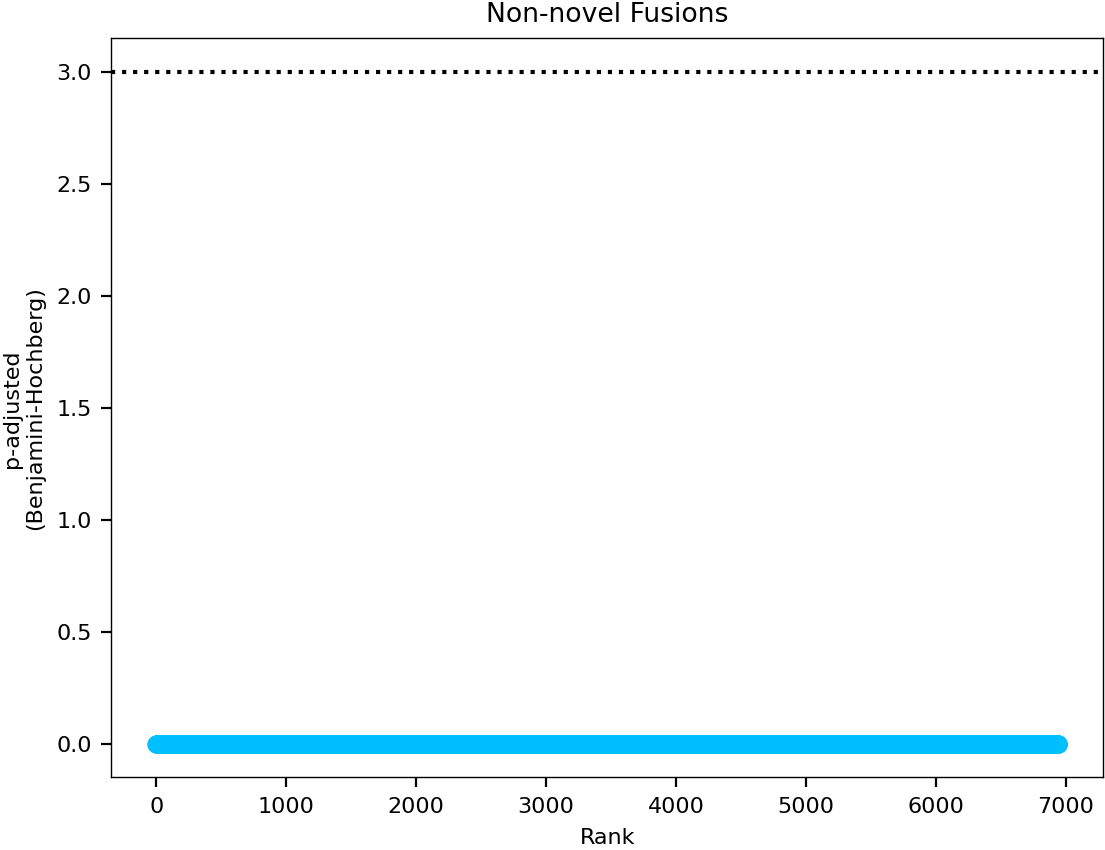

In [ ]:

yoffset = [3,3,3,-5,1,-5,-12,-15,-20,-20]
x = pd.DataFrame.from_dict(br_uni_res, orient='index').sort_values(0, ascending= True)
x.reset_index(inplace=True)
x['q'] = -1 * np.log10(stats.false_discovery_control(x[0], method='bh'))

ax = sns.scatterplot(x, y = 'q', x=range(len(x)), edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')
plt.title('Non-novel Fusions')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

Now what is being enriched for being left behind?

In [ ]:
# Grab all the domains from the n-grams of the proteins that make up the fusions
fusion_uniprots = list(set(fusion_info_OI.h_uniprot).union(fusion_info_OI.t_uniprot))
fusion_uni_dansy = dansy.dansy(protsOI=fusion_uniprots, ref = ref_df, n = 15,collapse = False)
potential_ngrams = fusion_uni_dansy.ngrams

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [ ]:
# Now we will look at what are the contributions 
M = fusion_group_uni.ngroups
full_cat_counts = Counter([g[2] for g in fusion_group_uni.groups])
res_list = []
fusion_prot_groups = fusion_info_OI.groupby(['h_uniprot', 't_uniprot','domain_architecture', 'dansy_impact'])

for ngram in tqdm(potential_ngrams):

    # To create a fair comparison need to only compare the fusions that had the potential to include that n-gram so going through and grabbing the groups with the proteins with it
    t = fusion_uni_dansy.retrieve_protein_info(ngram=ngram)
    t2 = fusion_info_OI[(fusion_info_OI.h_uniprot.isin(t['UniProt ID'])) | (fusion_info_OI.t_uniprot.isin(t['UniProt ID']))]
    t2 = t2.groupby(['fusion_protein_name','domain_architecture', 'dansy_impact'])
    groups2comp = t2.groups

    # for group in fusion_prot_groups.groups:
    #     if set(group[0:2]).intersection(t['UniProt ID']):
    #         groups2comp.append(group)
    M = t2.ngroups

    if M > 4: # Don't bother with too few to check
        i = pd.Series(index = ['Bridges', 'Reinforcement','Reintroduction','No Annotation','No Change','N'], name = ngram)
        for comp in ['Bridges', 'Reinforcement','Reintroduction','No Annotation','No Change']:
            N = 0
            n = 0
            x = 0
            for g in groups2comp:
                if g[2] == comp:
                    N += 1
                
                if ngram not in g[1]:
                    n += 1
                    if g[2] == comp:
                        x += 1
        
            i[comp] = stats.hypergeom.sf(x-1,M,n,N)
        i['N'] = M
        res_list.append(i)

100%|██████████| 20618/20618 [00:24<00:00, 825.45it/s]


In [ ]:
dropped_domains_res = pd.concat(res_list, axis = 1).T
dropped_domains_res

,Bridges,Reinforcement,Reintroduction,No Annotation,No Change,N
IPR013087,0.999967,1.0,0.852309,4.733084e-30,0.989445,444.0
IPR013087|IPR013087,0.999953,1.0,0.657920,2.892703e-26,0.991726,401.0
IPR000719,0.997137,1.0,0.260882,1.174677e-33,0.999999,554.0
IPR013087|IPR013087|IPR013087,0.999517,1.0,0.798362,4.177056e-23,0.991941,385.0
IPR013087|IPR013087|IPR013087|IPR013087,0.999328,1.0,0.866065,2.534301e-20,0.923786,362.0
...,...,...,...,...,...,...
IPR058766|IPR003593,1.000000,1.0,1.000000,6.000000e-01,0.600000,5.0
IPR058766,1.000000,1.0,1.000000,1.000000e-01,1.000000,5.0
IPR019082|IPR048452,1.000000,1.0,1.000000,1.000000e+00,1.000000,5.0
IPR048452,0.700000,1.0,1.000000,1.000000e+00,0.400000,5.0


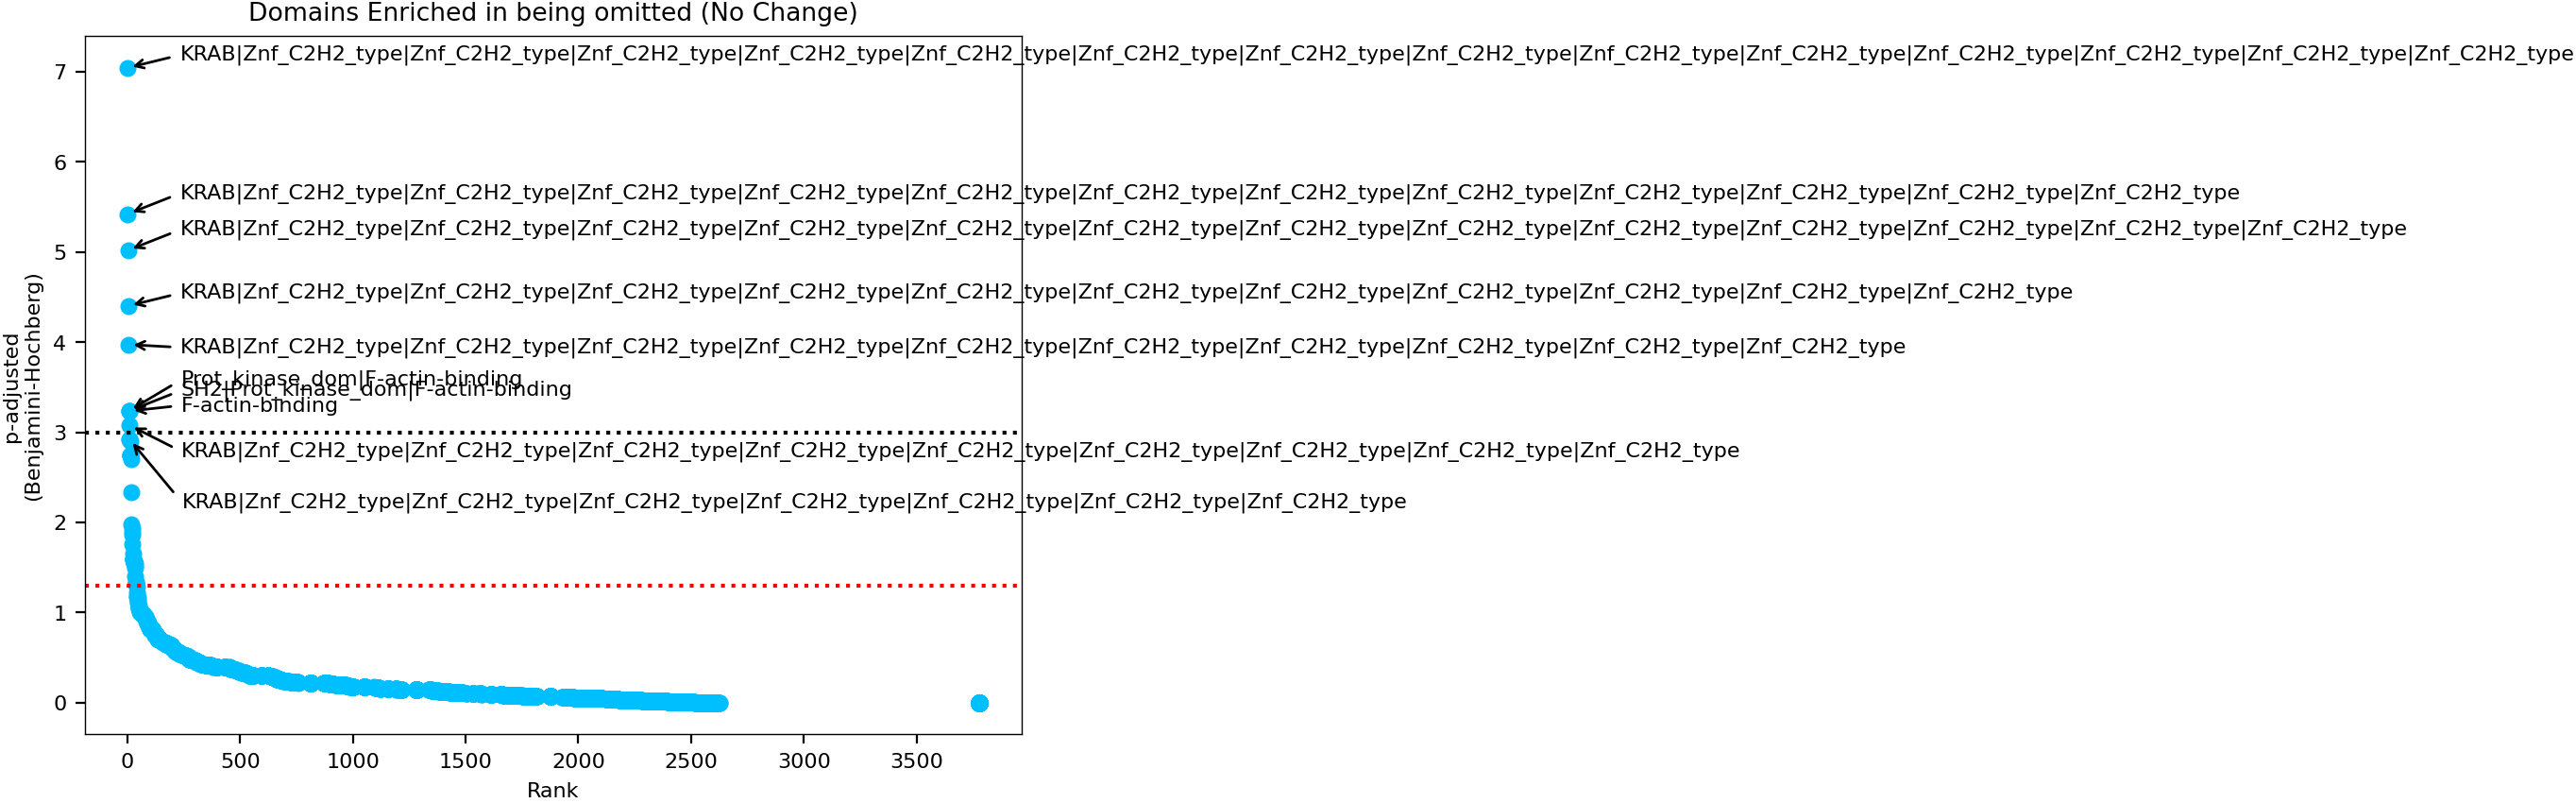

In [ ]:

yoffset = [3,6,6,3,-3,10,6,0,-12,-26]
x = dropped_domains_res.filter(['No Change'], axis = 1)
x['q'] = -1 * np.log10(x['No Change'])
x['rank'] = x['q'].rank(ascending = False)
x.sort_values('rank', inplace=True)
x.reset_index(inplace=True)
ax = sns.scatterplot(x, y = 'q', x='rank', edgecolor = None,color='deepskyblue')
plt.axhline(3, ls = ':', color = 'k')
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')

for i,ngram_info in x[0:10].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (i, ngram_info['q']),
                (xoffset,yoffset[i]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )

plt.title('Domains Enriched in being omitted (No Change)')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

## Combined gene effect score and domain enrichment

Now let's look at the breakpoints/fusions again but look at those that have a functional effect versus not.

In [ ]:
# Importing the dependency results
dep_res = pd.read_csv('Fusion_dependency_results.csv', index_col=0)
dep_res.dropna(subset=['domain_architecture', 'MDDS'], inplace=True)

In [ ]:
# Now setting up the domain enrichment analysis
alldoms = [x.split('|') for x in dep_res['domain_architecture'].values.tolist()]
alldoms = set(itertools.chain.from_iterable(alldoms))

dep_ngrams = [dansy.ngramUtilities.return_all_n_grams_from_key(x, domains=alldoms, max_ngram=15) for x in dep_res.domain_architecture]
dep_ngrams = itertools.chain.from_iterable(dep_ngrams)
dep_ngrams = set(dep_ngrams)

# Now let's fix up the ngram list to remove any specific to the fusions
dep_ngrams = list(dep_ngrams.intersection(full_proteome_ngrams))


In [ ]:
# Now we need to start doing the categorization and enrichment analysis.
M = len(dep_res)
N = sum(dep_res.potential_dependence)
dep_res_group = dep_res.groupby('potential_dependence')
dep_enrich_raw = {}
for ngram in dep_ngrams:
    n = sum([ngram in x for x in dep_res.domain_architecture])
    x = sum([ngram in i for i in dep_res_group.get_group(True).domain_architecture])
    dep_enrich_raw[ngram] = stats.hypergeom.sf(x-1,M,n,N)
    

In [ ]:
dep_enrich = pd.DataFrame.from_dict(dep_enrich_raw, orient='index')
dep_enrich.reset_index(inplace=True)
dep_enrich['n-gram'] = dep_enrich['index'].apply(proteome_net.return_legible_ngram)
dep_enrich['q'] = -1*np.log10(stats.false_discovery_control(dep_enrich[0], method='bh'))
dep_enrich['rank'] = dep_enrich['q'].rank(ascending= False)
dep_enrich.sort_values(0, inplace=True)

In [ ]:
dep_enrich

,index,0,n-gram,q,rank
1578,IPR001523,0.000027,Paired_dom,0.756923,1.5
7357,IPR000536,0.000036,Nucl_hrmn_rcpt_lig-bd,0.756923,1.5
5902,IPR000008|IPR001202|IPR001202|IPR001202|IPR001202,0.000104,C2_dom|WW_dom|WW_dom|WW_dom|WW_dom,0.609951,6.5
3704,IPR001628|IPR000536,0.000219,Znf_hrmn_rcpt|Nucl_hrmn_rcpt_lig-bd,0.609951,6.5
6679,IPR000418,0.000219,Ets_dom,0.609951,6.5
...,...,...,...,...,...
3269,IPR002909|IPR002909|IPR019316|IPR055401,1.000000,IPT_dom|IPT_dom|G8_domain|CEMIP_beta-hel_dom,-0.000000,4842.5
3270,IPR028074|IPR055362|IPR055363,1.000000,PHTB1_GAE_dom|PTHB1_pf_dom|PTHB1_hp_dom,-0.000000,4842.5
3271,IPR000742|IPR000742|IPR000742|IPR000742|IPR000...,1.000000,EGF|EGF|EGF|EGF|EGF|EGF|EGF|TEN_TTR-like,-0.000000,4842.5
3254,IPR018501,1.000000,DDT_dom,-0.000000,4842.5


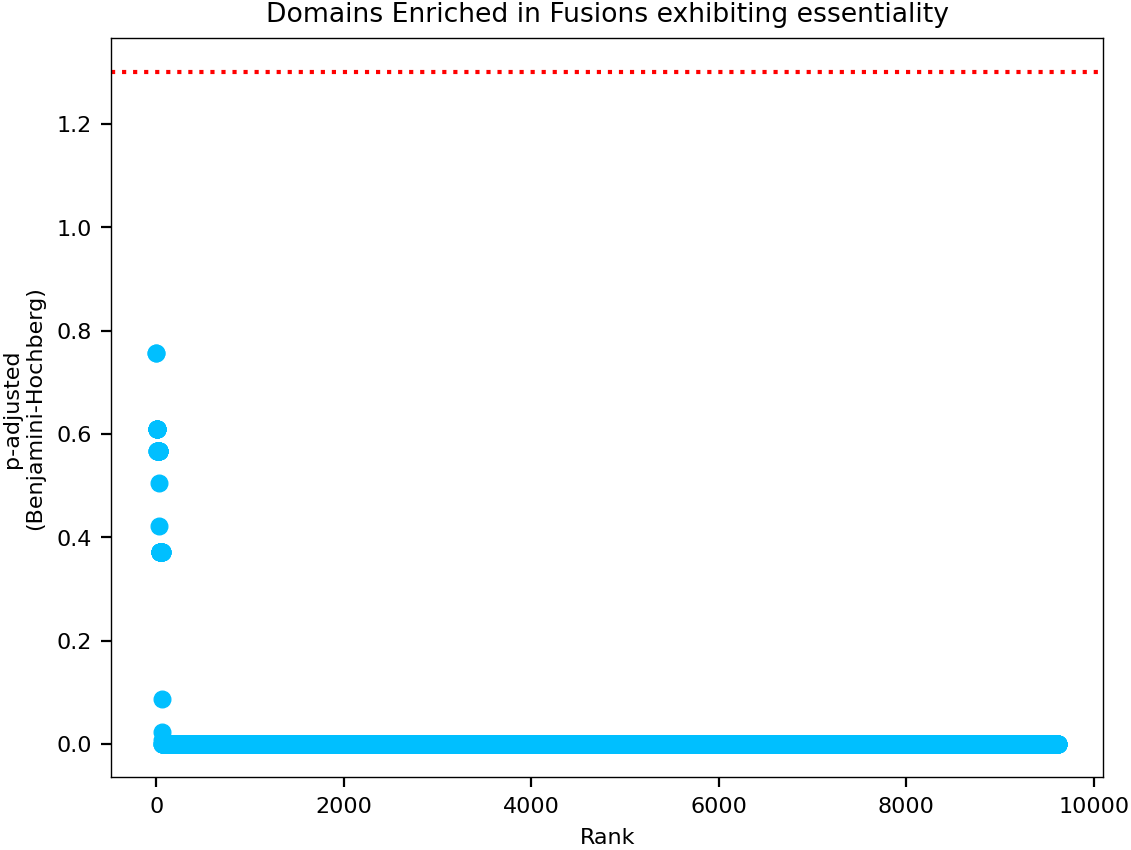

In [ ]:
sns.scatterplot(dep_enrich, x = range(len(dep_enrich)), y = 'q', edgecolor = None, color='deepskyblue')
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')
yoffset = [3,3,3,-5,1,-5,-12,-15,-20,-20]
# For the top 10 ngrams will label with their legible n-gram name
cnt = 0
for i,ngram_info in dep_enrich[0:5].iterrows():
    ax.annotate(proteome_net.return_legible_ngram(ngram_info['index']),
                (ngram_info['rank'], ngram_info['q']),
                (xoffset,yoffset[cnt]),
                textcoords='offset points',
                arrowprops={'arrowstyle':"->",
                            'relpos':(0,0.5)},
                )
    cnt += 1


plt.title('Domains Enriched in Fusions exhibiting essentiality')
plt.ylabel('p-adjusted\n(Benjamini-Hochberg)', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

Okay so that doesn't suggest anything in particular which makes this a bit of a dud unfortunately...

Well, last ditch effort of doing this now with the TCGA data but looking at potential recurrence state across cancers as well as the DANSy categories

# TCGA domain enrichment

In [ ]:
tcga_dansy_res = pd.read_csv('TCGA_Fusion_DANSY_Summary.csv', index_col=0,na_values=None)
tcga_dansy_res.dropna(subset=['dansy_impact'], inplace=True)
tcga_dansy_res.domain_architecture.fillna('', inplace=True)
print(f'There are {len(tcga_dansy_res)} breakpoints available for analysis.')

There are 25421 breakpoints available for analysis.


In [ ]:
# Now we filter out the results to those that did not involve only proteins with no domain annotations ot start
nodomprots = ref_df[ref_df['Interpro Domain Architecture IDs'] == '']['UniProt ID'].tolist()
tcga_dansy_res['no_dom_2_start'] = tcga_dansy_res.apply(lambda row: row.h_uniprot in nodomprots and row.t_uniprot in nodomprots, axis = 1)
tcga_dansy_res = tcga_dansy_res[~tcga_dansy_res.no_dom_2_start]
print(f'There are {len(tcga_dansy_res)} breakpoints available for analysis.')

There are 24525 breakpoints available for analysis.


In [ ]:
# Now let's grab all the n-grams from the domain architectures and filter to those found within the proteome
alldoms = [x.split('|') for x in tcga_dansy_res['domain_architecture'].values.tolist()]
alldoms = set(itertools.chain.from_iterable(alldoms))

tcga_ngrams = [dansy.ngramUtilities.return_all_n_grams_from_key(x, domains=alldoms, max_ngram=15) for x in tcga_dansy_res.domain_architecture]
tcga_ngrams = itertools.chain.from_iterable(tcga_ngrams)
tcga_ngrams = set(tcga_ngrams)

# Now let's fix up the ngram list to remove any specific to the fusions
tcga_ngrams = list(tcga_ngrams.intersection(full_proteome_ngrams))


In [ ]:
# Let's repeat the domain enrichment analysis but not limited to any specific cancer type
M = len(tcga_dansy_res)
tcga_grouped = tcga_dansy_res.groupby('dansy_impact')
tcga_N = Counter(tcga_dansy_res.dansy_impact)
full_tcga_raw = []
for ngram in tqdm(tcga_ngrams):
    n = sum([ngram in i for i in tcga_dansy_res.domain_architecture])
    res = pd.Series(index = tcga_N.keys(),name = ngram)
    res['n'] = n
    for comp in tcga_N.keys():
        temp = tcga_grouped.get_group(comp)
        x = sum([ngram in i for i in temp.domain_architecture])
        res[comp] = stats.hypergeom.sf(x-1,M,n,N)
    full_tcga_raw.append(res)
    



100%|██████████| 16098/16098 [01:34<00:00, 170.99it/s]


In [ ]:
full_tcga_res = pd.concat(full_tcga_raw, axis =1).T
full_tcga_res.reset_index(inplace= True)
full_tcga_res['n-gram'] = full_tcga_res['index'].apply(proteome_net.return_legible_ngram)
full_tcga_res.sort_values('Bridges', inplace=True)

for comp in tcga_N.keys():
    full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))

full_tcga_res = full_tcga_res.mask(full_tcga_res == -0)

/var/folders/3q/_kyvxhrx2zv25qm8x2nv6c0h0000gr/T/ipykernel_37045/2185456001.py:7: RuntimeWarning: divide by zero encountered in log10
  full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))
/var/folders/3q/_kyvxhrx2zv25qm8x2nv6c0h0000gr/T/ipykernel_37045/2185456001.py:7: RuntimeWarning: divide by zero encountered in log10
  full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))
/var/folders/3q/_kyvxhrx2zv25qm8x2nv6c0h0000gr/T/ipykernel_37045/2185456001.py:7: RuntimeWarning: divide by zero encountered in log10
  full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))


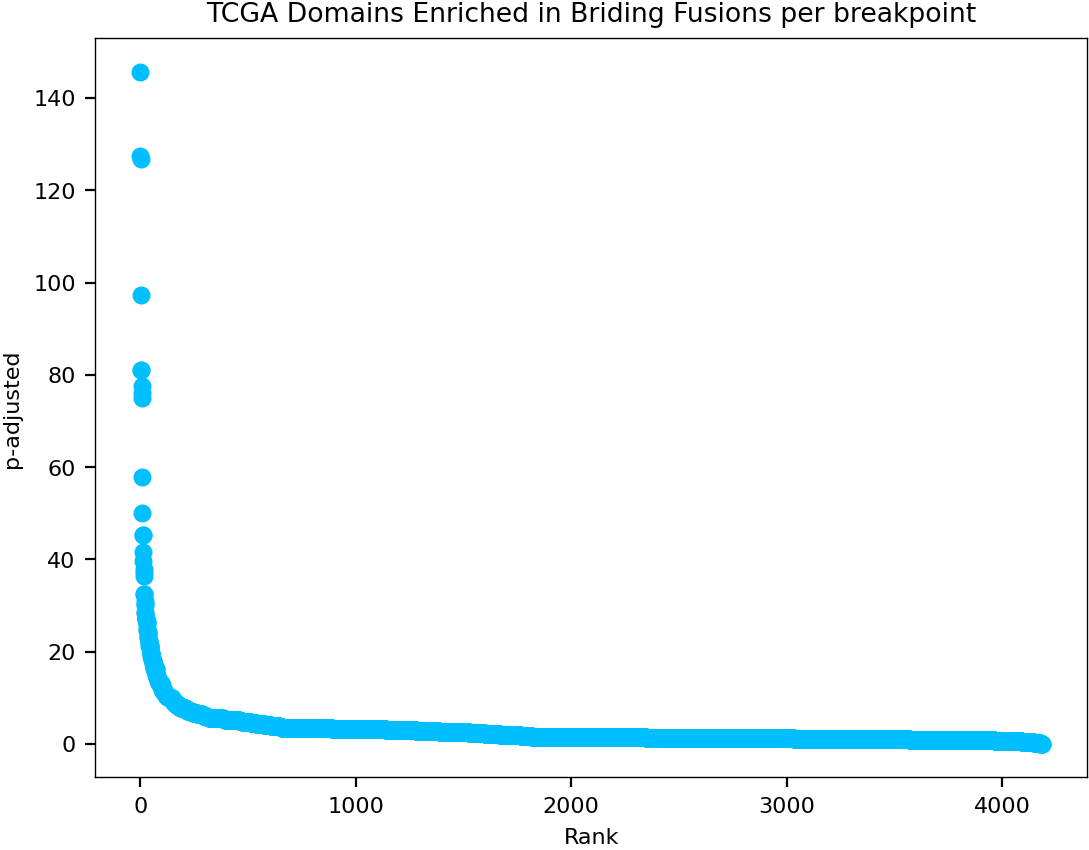

In [ ]:
sns.scatterplot(full_tcga_res, x = range(len(full_tcga_res)), y = 'Bridges_q', edgecolor = None, color = 'deepskyblue')
plt.title('TCGA Domains Enriched in Briding Fusions per breakpoint')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

As kinda shown above with the CCLE dataset there are far too many "signficant" n-grams that I believe are being buoyed by single fusion proteins having multiple breakpoints. So will do the same thing as above where I first whittle down the analyzed domain architectures to those with single dansy impacts within a patient followed by overall domain architectures per fusion protein (not instances).

In [ ]:
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture','dansy_impact','BarcodeID'])
M = tcga_grouped.ngroups
tcga_N = Counter([g[2] for g in tcga_grouped.groups])
full_tcga_raw = []
for ngram in tqdm(tcga_ngrams):
    n = sum([ngram in i[1] for i in tcga_grouped.groups])
    res = pd.Series(index = tcga_N.keys(),name = ngram)
    res['n'] = n
    for comp in tcga_N.keys():
        N= tcga_N[comp]
        temp = [g[1] for g in tcga_grouped.groups if g[2] == comp]
        x = sum([ngram in i for i in temp])
        res[comp] = stats.hypergeom.sf(x-1,M,n,N)
    
        if ngram == 'IPR000719':
            print(f'Kinase: N{N}, M{M}, x{x}, n{n}')
    full_tcga_raw.append(res)
    

 28%|██▊       | 4529/16098 [00:23<01:00, 192.63it/s]

Kinase: N9024, M21651, x414, n689
Kinase: N2931, M21651, x59, n689
Kinase: N6909, M21651, x0, n689
Kinase: N1193, M21651, x71, n689
Kinase: N1594, M21651, x145, n689


100%|██████████| 16098/16098 [01:23<00:00, 193.93it/s]


In [ ]:
full_tcga_res = pd.concat(full_tcga_raw, axis =1).T
full_tcga_res.reset_index(inplace= True)
full_tcga_res['n-gram'] = full_tcga_res['index'].apply(proteome_net.return_legible_ngram)
full_tcga_res.sort_values('Bridges', inplace=True)

for comp in tcga_N.keys():
    full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))

full_tcga_res = full_tcga_res.mask(full_tcga_res == -0,0)

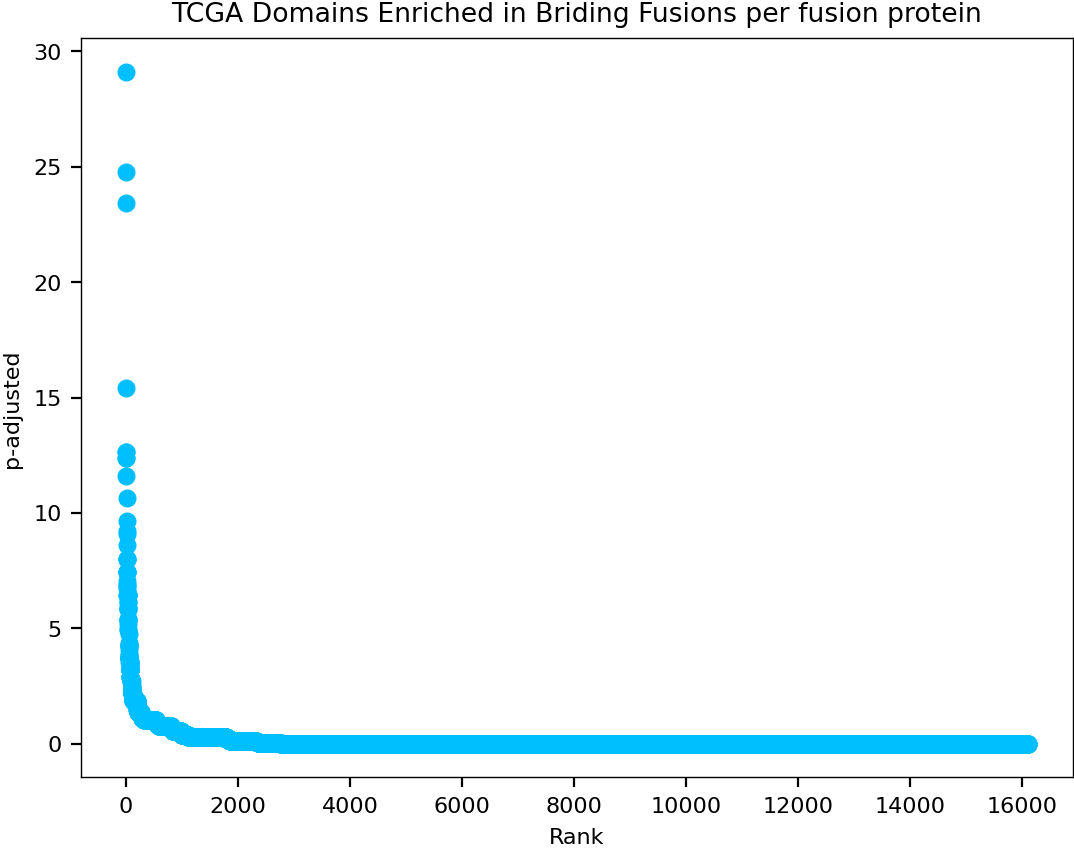

In [ ]:
sns.scatterplot(full_tcga_res, x = range(len(full_tcga_res)), y = 'Bridges_q', edgecolor = None, color = 'deepskyblue')
plt.title('TCGA Domains Enriched in Briding Fusions per fusion protein')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
full_tcga_res

,index,No Change,Reintroduction,No Annotation,Bridges,Reinforcement,n,n-gram,No Change_q,Reintroduction_q,No Annotation_q,Bridges_q,Reinforcement_q
8077,IPR001628,0.398241,0.966546,1.0,4.854354e-34,1.000000,99.0,Znf_hrmn_rcpt,0.000000,0.000000,0.0,29.107097,0.000000
6297,IPR001628|IPR000536,0.049169,1.000000,1.0,2.082996e-29,1.000000,84.0,Znf_hrmn_rcpt|Nucl_hrmn_rcpt_lig-bd,0.000000,0.000000,0.0,24.775570,0.000000
12372,IPR000536,0.003786,1.000000,1.0,6.826727e-28,1.000000,95.0,Nucl_hrmn_rcpt_lig-bd,0.572939,0.000000,0.0,23.436137,0.000000
11713,IPR003619,0.177921,1.000000,1.0,9.392693e-20,1.000000,51.0,MAD_homology1_Dwarfin-type,0.000000,0.000000,0.0,15.422498,0.000000
14808,IPR001841|IPR000315|IPR000315,0.999998,0.993875,1.0,8.392457e-17,0.000027,35.0,Znf_RING|Znf_B-box|Znf_B-box,0.000000,0.000000,0.0,12.647490,2.811314
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6165,IPR019167,0.030166,1.000000,1.0,1.000000e+00,1.000000,4.0,PAT1_dom,0.128176,0.000000,0.0,0.000000,0.000000
6166,IPR003598|IPR003598|IPR003599|IPR003598|IPR003599,1.000000,0.135375,1.0,1.000000e+00,1.000000,1.0,Ig_sub2|Ig_sub2|Ig_sub|Ig_sub2|Ig_sub,0.000000,0.460247,0.0,0.000000,0.000000
6167,IPR040849|IPR003599|IPR003598|IPR003599,1.000000,1.000000,1.0,1.000000e+00,0.073622,1.0,MyBP-C_THB|Ig_sub|Ig_sub2|Ig_sub,0.000000,0.000000,0.0,0.000000,0.510436
6169,IPR013087|IPR013087|IPR003604|IPR013087|IPR003...,1.000000,0.135375,1.0,1.000000e+00,1.000000,1.0,Znf_C2H2_type|Znf_C2H2_type|Matrin/U1-like-C_Z...,0.000000,0.460247,0.0,0.000000,0.000000


In [ ]:
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture','dansy_impact'])
M = tcga_grouped.ngroups
tcga_N = Counter([g[2] for g in tcga_grouped.groups])
full_tcga_raw = []
for ngram in tqdm(tcga_ngrams):
    n = sum([ngram in i[1] for i in tcga_grouped.groups])
    res = pd.Series(index = tcga_N.keys(),name = ngram)
    res['n'] = n
    for comp in tcga_N.keys():
        N= tcga_N[comp]
        temp = [g[1] for g in tcga_grouped.groups if g[2] == comp]
        x = sum([ngram in i for i in temp])
        res[comp] = stats.hypergeom.sf(x-1,M,n,N)
    
        if ngram == 'IPR000719':
            print(f'Kinase: N{N}, M{M}, x{x}, n{n}')
    full_tcga_raw.append(res)

full_tcga_res = pd.concat(full_tcga_raw, axis =1).T
full_tcga_res.reset_index(inplace= True)
full_tcga_res['n-gram'] = full_tcga_res['index'].apply(proteome_net.return_legible_ngram)
full_tcga_res.sort_values('Bridges', inplace=True)

for comp in tcga_N.keys():
    full_tcga_res[comp+'_q'] = -1*np.log10(stats.false_discovery_control(full_tcga_res[comp], method = 'bh'))

full_tcga_res = full_tcga_res.mask(full_tcga_res == -0,0)

 28%|██▊       | 4535/16098 [00:17<00:43, 267.60it/s]

Kinase: N6131, M15057, x255, n448
Kinase: N2056, M15057, x45, n448
Kinase: N4776, M15057, x0, n448
Kinase: N882, M15057, x45, n448
Kinase: N1212, M15057, x103, n448


100%|██████████| 16098/16098 [01:00<00:00, 265.97it/s]


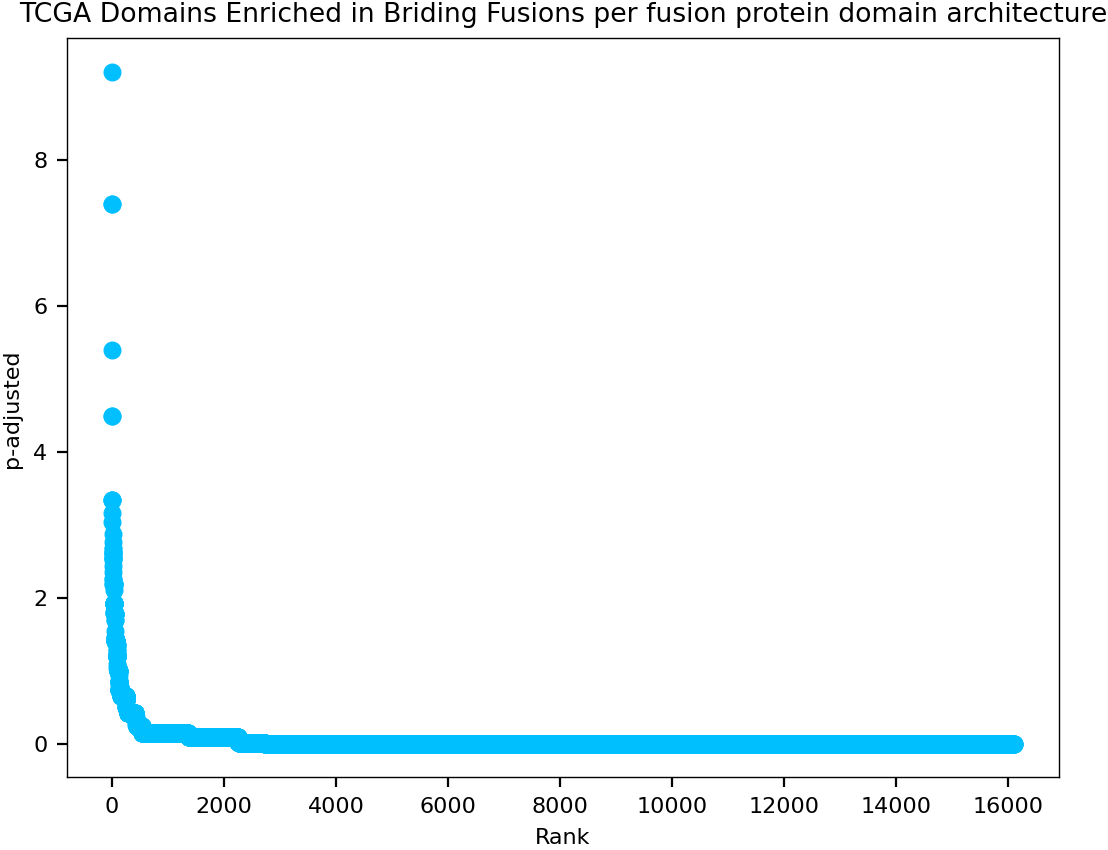

In [ ]:
sns.scatterplot(full_tcga_res, x = range(len(full_tcga_res)), y = 'Bridges_q', edgecolor = None, color = 'deepskyblue')
plt.title('TCGA Domains Enriched in Briding Fusions per fusion protein domain architecture')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
full_tcga_res

,index,No Change,Reintroduction,No Annotation,Bridges,Reinforcement,n,n-gram,No Change_q,Reintroduction_q,No Annotation_q,Bridges_q,Reinforcement_q
11713,IPR003619,0.158457,1.000000,1.0,3.918481e-14,1.000000,38.0,MAD_homology1_Dwarfin-type,0.000000,0.000000,0.0,9.200110,0.00000
11438,IPR019548|IPR003619,0.138941,1.000000,1.0,7.653505e-12,1.000000,33.0,CTF/NFI_DNA-bd_N|MAD_homology1_Dwarfin-type,0.000000,0.000000,0.0,7.386489,0.00000
10695,IPR019548,0.138941,1.000000,1.0,7.653505e-12,1.000000,33.0,CTF/NFI_DNA-bd_N,0.000000,0.000000,0.0,7.386489,0.00000
8077,IPR001628,0.006581,0.887176,1.0,1.020548e-09,1.000000,55.0,Znf_hrmn_rcpt,0.100492,0.000000,0.0,5.386455,0.00000
3124,IPR005481,0.993728,0.023065,1.0,1.018263e-08,1.000000,22.0,BC-like_N,0.000000,0.692725,0.0,4.493415,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6165,IPR019167,0.067492,1.000000,1.0,1.000000e+00,1.000000,3.0,PAT1_dom,0.000000,0.000000,0.0,0.000000,0.00000
6166,IPR003598|IPR003598|IPR003599|IPR003598|IPR003599,1.000000,0.136548,1.0,1.000000e+00,1.000000,1.0,Ig_sub2|Ig_sub2|Ig_sub|Ig_sub2|Ig_sub,0.000000,0.433117,0.0,0.000000,0.00000
6167,IPR040849|IPR003599|IPR003598|IPR003599,1.000000,1.000000,1.0,1.000000e+00,0.080494,1.0,MyBP-C_THB|Ig_sub|Ig_sub2|Ig_sub,0.000000,0.000000,0.0,0.000000,0.41056
6169,IPR013087|IPR013087|IPR003604|IPR013087|IPR003...,1.000000,0.136548,1.0,1.000000e+00,1.000000,1.0,Znf_C2H2_type|Znf_C2H2_type|Matrin/U1-like-C_Z...,0.000000,0.433117,0.0,0.000000,0.00000


 28%|██▊       | 4579/16098 [00:07<00:18, 611.86it/s]

Kinase: N2094, M15057, x148, n448


100%|██████████| 16098/16098 [00:25<00:00, 628.28it/s]


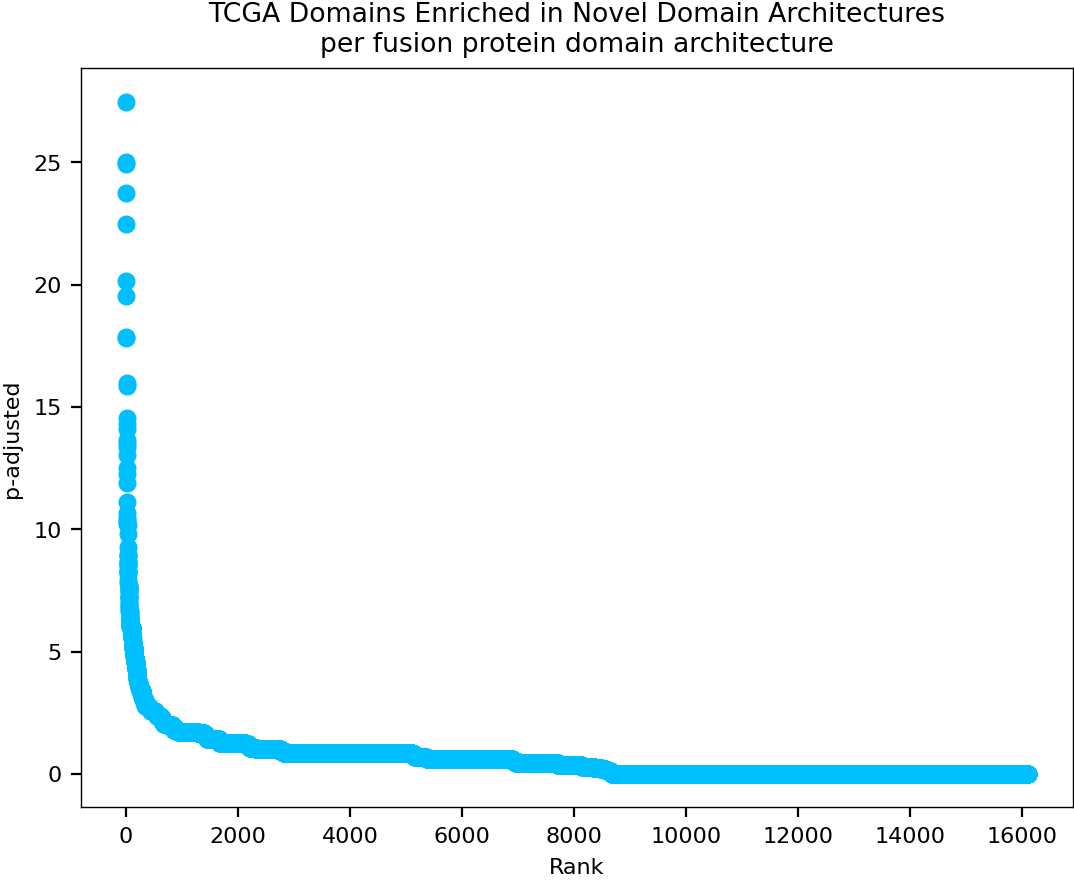

In [ ]:
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture','dansy_impact'])
M = tcga_grouped.ngroups
N = tcga_N['Bridges'] + tcga_N['Reinforcement']
full_tcga_raw = []
for ngram in tqdm(tcga_ngrams):
    n = sum([ngram in i[1] for i in tcga_grouped.groups])
    res = pd.Series(index = ['Novel_Architecture'],name = ngram)
    res['n'] = n
    temp = [g[1] for g in tcga_grouped.groups if g[2] in ['Bridges','Reinforcement']]
    x = sum([ngram in i for i in temp])
    res['Novel_Architecture'] = stats.hypergeom.sf(x-1,M,n,N)
    
    if ngram == 'IPR000719':
        print(f'Kinase: N{N}, M{M}, x{x}, n{n}')
    full_tcga_raw.append(res)

full_tcga_res = pd.concat(full_tcga_raw, axis =1).T
full_tcga_res.reset_index(inplace= True)
full_tcga_res['n-gram'] = full_tcga_res['index'].apply(proteome_net.return_legible_ngram)
full_tcga_res.sort_values('Novel_Architecture', inplace=True)
full_tcga_res['Novel_Architecture_q'] = -1*np.log10(full_tcga_res['Novel_Architecture'])


full_tcga_res = full_tcga_res.mask(full_tcga_res == -0,0)
sns.scatterplot(full_tcga_res, x = range(len(full_tcga_res)), y = 'Novel_Architecture_q', edgecolor = None, color = 'deepskyblue')
plt.title('TCGA Domains Enriched in Novel Domain Architectures\nper fusion protein domain architecture')
plt.ylabel('p-adjusted', size = 8)
plt.xlabel('Rank', size=8)
plt.show()

In [ ]:
full_tcga_res

,index,Novel_Architecture,n,n-gram,Novel_Architecture_q
9256,IPR013087,3.334726e-28,388.0,Znf_C2H2_type,27.476940
4490,IPR000719,9.572304e-26,448.0,Prot_kinase_dom,25.018984
2531,IPR001452,1.143155e-25,343.0,SH3_domain,24.941895
12312,IPR000742,1.750585e-24,268.0,EGF,23.756817
3516,IPR001841,3.340451e-23,236.0,Znf_RING,22.476195
...,...,...,...,...,...
7452,IPR039007|IPR039006,1.000000e+00,4.0,pG1|RhoGAP_pG2,0.000000
7453,IPR021869,1.000000e+00,2.0,RNase_Zc3h12_NYN,0.000000
7454,IPR013087|IPR013087|IPR013087|IPR013087|IPR003...,1.000000e+00,1.0,Znf_C2H2_type|Znf_C2H2_type|Znf_C2H2_type|Znf_...,0.000000
7442,IPR001356|IPR013087|IPR013087|IPR001356|IPR013...,1.000000e+00,2.0,HD|Znf_C2H2_type|Znf_C2H2_type|HD|Znf_C2H2_typ...,0.000000


Now for the opposite which looks at which domains are being left behind

In [ ]:
tcga_dansy_res

,name,h_gene,t_gene,h_uniprot,t_uniprot,h_chr,t_chr,h_pos,t_pos,h_strand,t_strand,id,domain_architecture,BarcodeID,Cancertype,dansy_impact,no_dom_2_start
0,TXNDC11-CIB4,ENSG00000153066,ENSG00000157884,Q6PKC3,A0PJX0,chr16,chr2,11736016,26640567,-,-,DANSY_00005,IPR002048,TCGA-OR-A5K5,ACC,No Change,False
1,GPR98-CLPTM1L,ENSG00000164199,ENSG00000049656,Q8WXG9,Q96KA5,chr5,chr5,90985522,1318453,+,-,DANSY_00010,IPR003644|IPR003644|IPR003644|IPR003644|IPR003...,TCGA-OR-A5JV,ACC,Reintroduction,False
2,KIF1B-FAM58A,ENSG00000054523,ENSG00000262919,O60333,Q8N1B3,chr1,chrX,10232434,153596187,+,-,DANSY_00011,IPR013763,TCGA-OR-A5J7,ACC,No Change,False
3,SCMH1-CA6,ENSG00000010803,ENSG00000131686,Q96GD3,P23280,chr1,chr1,41033982,8949262,-,+,DANSY_00014,IPR033763|IPR021987,TCGA-OR-A5J7,ACC,Reintroduction,False
4,AP2A2-DRD4,ENSG00000183020,ENSG00000069696,O94973,P21917,chr11,chr11,977224,639432,+,+,DANSY_00016,,TCGA-OR-A5J7,ACC,No Annotation,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25419,TMPRSS2-ERG,ENSG00000184012,ENSG00000157554,O15393,P11308,chr21,chr21,41508081,38445621,'-','-',DANSY_132972,IPR003118|IPR000418,TCGA-ZG-A9L4-01A,PRAD,No Change,False
25420,TMPRSS2-ERG,ENSG00000184012,ENSG00000157554,O15393,P11308,chr21,chr21,41508081,38584945,'-','-',DANSY_132973,IPR003118|IPR000418,TCGA-ZG-A9L9-01A,PRAD,No Change,False
25421,TMPRSS2-ERG,ENSG00000184012,ENSG00000157554,O15393,P11308,chr21,chr21,41508081,38445621,'-','-',DANSY_132974,IPR003118|IPR000418,TCGA-ZG-A9LZ-01A,PRAD,No Change,False
25422,TMPRSS2-ERG,ENSG00000184012,ENSG00000157554,O15393,P11308,chr21,chr21,41508081,38584945,'-','-',DANSY_132975,IPR003118|IPR000418,TCGA-ZG-A9MC-01A,PRAD,No Change,False


In [ ]:
# Now we will look at what are the domains being lost

# Grab all the domains from the n-grams of the proteins that make up the fusions
fusion_uniprots = list(set(tcga_dansy_res.h_uniprot).union(tcga_dansy_res.t_uniprot))
fusion_uni_dansy = dansy.dansy(protsOI=fusion_uniprots, ref = ref_df, n = 15,collapse = False)
potential_ngrams = fusion_uni_dansy.ngrams
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture','dansy_impact'])
fusion_prot_groups = tcga_dansy_res.groupby(['h_uniprot', 't_uniprot','domain_architecture', 'dansy_impact'])


Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [ ]:
cats2check = ['Reinforcement', 'Bridges']
res_list = []
for ngram in tqdm(potential_ngrams):

    # To create a fair comparison need to only compare the fusions that had the potential to include that n-gram so going through and grabbing the groups with the proteins with it
    t = fusion_uni_dansy.retrieve_protein_info(ngram=ngram)
    t2 = tcga_dansy_res[(tcga_dansy_res.h_uniprot.isin(t['UniProt ID'])) | (tcga_dansy_res.t_uniprot.isin(t['UniProt ID']))]
    t2 = t2.groupby(['name','domain_architecture', 'dansy_impact'])
    groups2comp = t2.groups

    M = t2.ngroups
    
    if M > 4: # Don't bother with too few to check
        i = pd.Series(index = ['pval','M','N','x','n'], name = ngram)
        N = sum([g[2] in cats2check for g in groups2comp])
        n = sum([ngram not in g[1] for g in groups2comp])
        temp = [g[1] for g in groups2comp if g[2] in cats2check]
        x  = sum([ngram not in i for i in temp])
    
        i['pval'] = stats.hypergeom.sf(x-1,M,n,N)
        i[['M','N','n','x']] = [M,N,n,x]

        res_list.append(i)

100%|██████████| 24345/24345 [00:42<00:00, 579.46it/s]


In [ ]:
dropped_domains_res = pd.concat(res_list, axis = 1).T
dropped_domains_res.reset_index(inplace=True)
dropped_domains_res['n-gram'] = dropped_domains_res['index'].apply(proteome_net.return_legible_ngram)
dropped_domains_res['q']=stats.false_discovery_control(dropped_domains_res.pval, method = 'bh')
dropped_domains_res['log_q'] = -1*np.log10(dropped_domains_res.q)
dropped_domains_res.sort_values(by = 'pval')

,index,pval,M,N,x,n,n-gram,q,log_q
1479,IPR009048,0.017857,16.0,3.0,3.0,5.0,A-macroglobulin_rcpt-bd,1.0,-0.0
593,IPR027936|IPR000719|IPR001660,0.020703,26.0,10.0,8.0,13.0,Eph_TM|Prot_kinase_dom|SAM,1.0,-0.0
596,IPR000719|IPR001660,0.020703,26.0,10.0,8.0,13.0,Prot_kinase_dom|SAM,1.0,-0.0
597,IPR027936|IPR000719,0.020703,26.0,10.0,8.0,13.0,Eph_TM|Prot_kinase_dom,1.0,-0.0
5157,IPR029295|IPR001487,0.021900,27.0,7.0,7.0,17.0,SnAC|Bromodomain,1.0,-0.0
...,...,...,...,...,...,...,...,...,...
6128,IPR004148|IPR000198,1.000000,7.0,0.0,0.0,6.0,BAR_dom|RhoGAP_dom,1.0,-0.0
6126,IPR022084,1.000000,7.0,1.0,0.0,5.0,TF_Elf_N,1.0,-0.0
6125,IPR022084|IPR000418,1.000000,7.0,1.0,0.0,5.0,TF_Elf_N|Ets_dom,1.0,-0.0
6278,IPR014890,1.000000,12.0,7.0,0.0,2.0,c-SKI_SMAD4-bd_dom,1.0,-0.0


In [ ]:
bc = nx.betweenness_centrality(proteome_net.G)
d = nx.degree_centrality(proteome_net.G)

In [ ]:
reps = {}
for ngram in full_tcga_res['index']:
    temp = proteome_net.retrieve_protein_info(ngram = ngram)
    reps[ngram] = len(temp)

In [ ]:
full_tcga_res['betweenness'] = full_tcga_res['index'].map(bc)
full_tcga_res['degree'] = full_tcga_res['index'].map(d)
full_tcga_res['proteins'] = full_tcga_res['index'].map(reps)

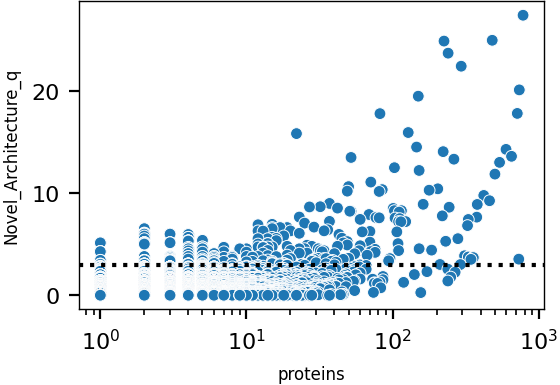

In [ ]:
sns.scatterplot(full_tcga_res, x = 'proteins', y = 'Novel_Architecture_q', size = 1, legend=None)
plt.xscale('log')
plt.axhline(3,ls = ':', color ='k')
plt.gcf().set_size_inches(3,2)
plt.show()


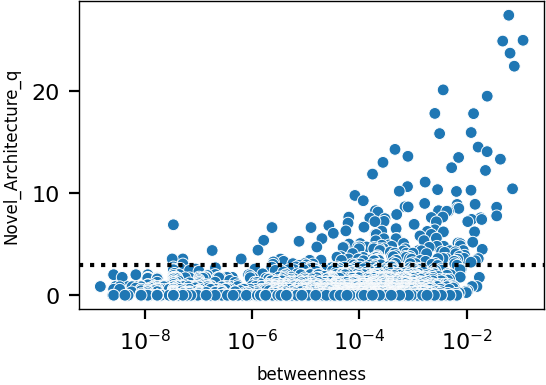

In [ ]:
sns.scatterplot(full_tcga_res, x = 'betweenness', y = 'Novel_Architecture_q', size = 1, legend=None)
plt.xscale('log')
plt.axhline(3,ls = ':', color ='k')
plt.gcf().set_size_inches(3,2)
plt.show()


In [ ]:
stats.spearmanr(full_tcga_res['Novel_Architecture_q'], full_tcga_res['betweenness'].apply(lambda x: np.log10(x+1)),nan_policy='omit',alternative='greater')

SignificanceResult(statistic=0.20132457122324499, pvalue=3.0786530218679505e-39)

In [ ]:
stats.spearmanr(full_tcga_res['Novel_Architecture_q'], full_tcga_res['proteins'].apply(lambda x: np.log10(x+1)),nan_policy='omit',alternative='greater')

SignificanceResult(statistic=0.27213140719544465, pvalue=1.3745083835922982e-271)

# Cleaned-up Analysis

Because there was a lot of exploring and I have created a new module to streamline the enrichment analysis, I am generating the plots of interest below as I figure out what needs to be removed and retained from above.

In [8]:
nat_ngrams = dansy.ngramUtilities.return_ngrams_from_list(ref_df['Interpro Domain Architecture IDs'], 15)

In [9]:
ccle_full_dansy = dansy_sum.merge(ccle_model_info.filter(['ModelID', 'OncotreeLineage', 'StrippedCellLineName']), left_on='ModelID',right_on='ModelID')
ccle_unique_fusions = ccle_full_dansy.filter(['fusion_protein_name','dansy_impact','domain_architecture']).drop_duplicates().dropna(subset='dansy_impact')
ccle_unique_fusions['novel_arch'] = ccle_unique_fusions.dansy_impact.apply(lambda x: str(x in ['Bridges','Reinforcement']))
ccle_unique_fusions.domain_architecture.fillna('',inplace=True)

In [10]:
# Get the list of n-grams from the domain architectures
ccle_ngrams = dansy.ngramUtilities.return_ngrams_from_list(ccle_unique_fusions.domain_architecture,5) # Don't bother with beyond 5-grams
ccle_ngrams_preexist = sorted(set(ccle_ngrams).intersection(nat_ngrams))

In [11]:
enrich_ccle_dansy = EnrichementAnalysis.EnrichmentAnalysis(ccle_unique_fusions, ccle_ngrams_preexist,{'category':'dansy_impact','domain_architecture':'domain_architecture'})

100%|██████████| 8267/8267 [00:16<00:00, 512.28it/s]


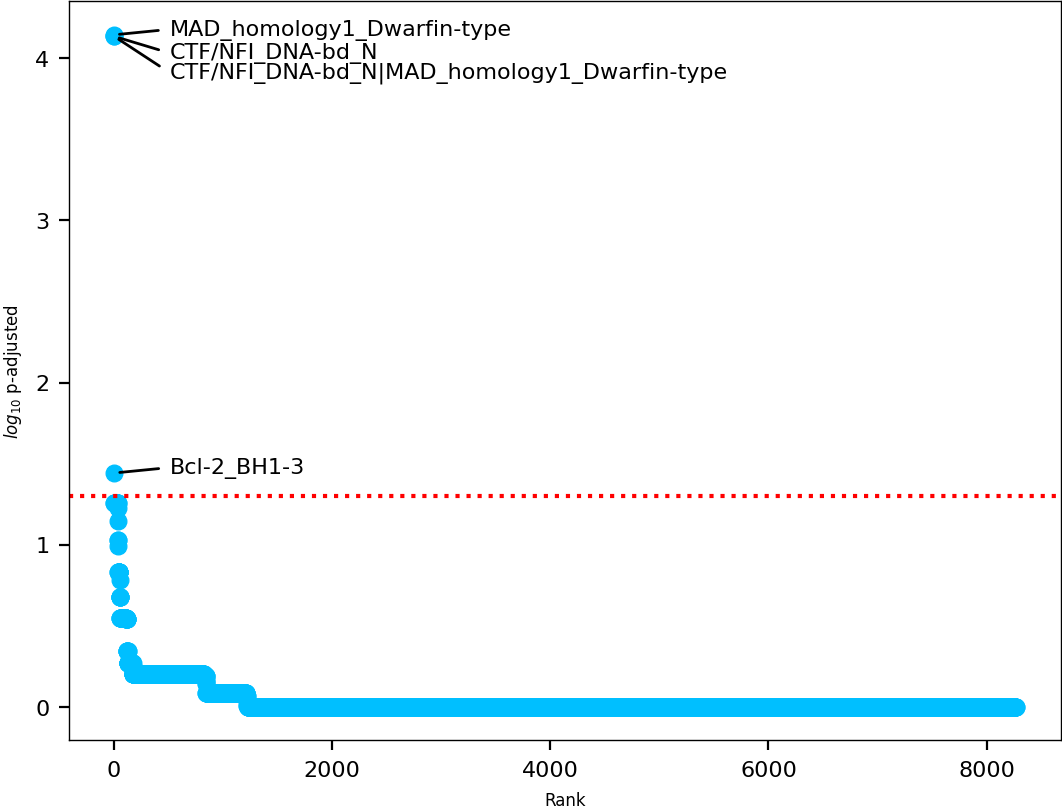

In [12]:
colOI = 'Bridges'
enrich_ccle_dansy.plot(colOI)
ax = plt.gca()
n = sum(enrich_ccle_dansy.res.Bridges_q.le(0.05))
EnrichementAnalysis.add_top_ngram_annotations(ax, enrich_ccle_dansy.res, proteome_net,cat=colOI,n=n,yoffset=[0,-8,-15,0,20,12,6,0,-6,-15])
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')


In [13]:
enrich_ccle_novel = EnrichementAnalysis.EnrichmentAnalysis(ccle_unique_fusions, ccle_ngrams_preexist,{'category':'novel_arch','domain_architecture':'domain_architecture'})

100%|██████████| 8267/8267 [00:13<00:00, 597.46it/s]


Text(0.5, 1.0, 'Novel Domain Architectures\nEnriched Domains')

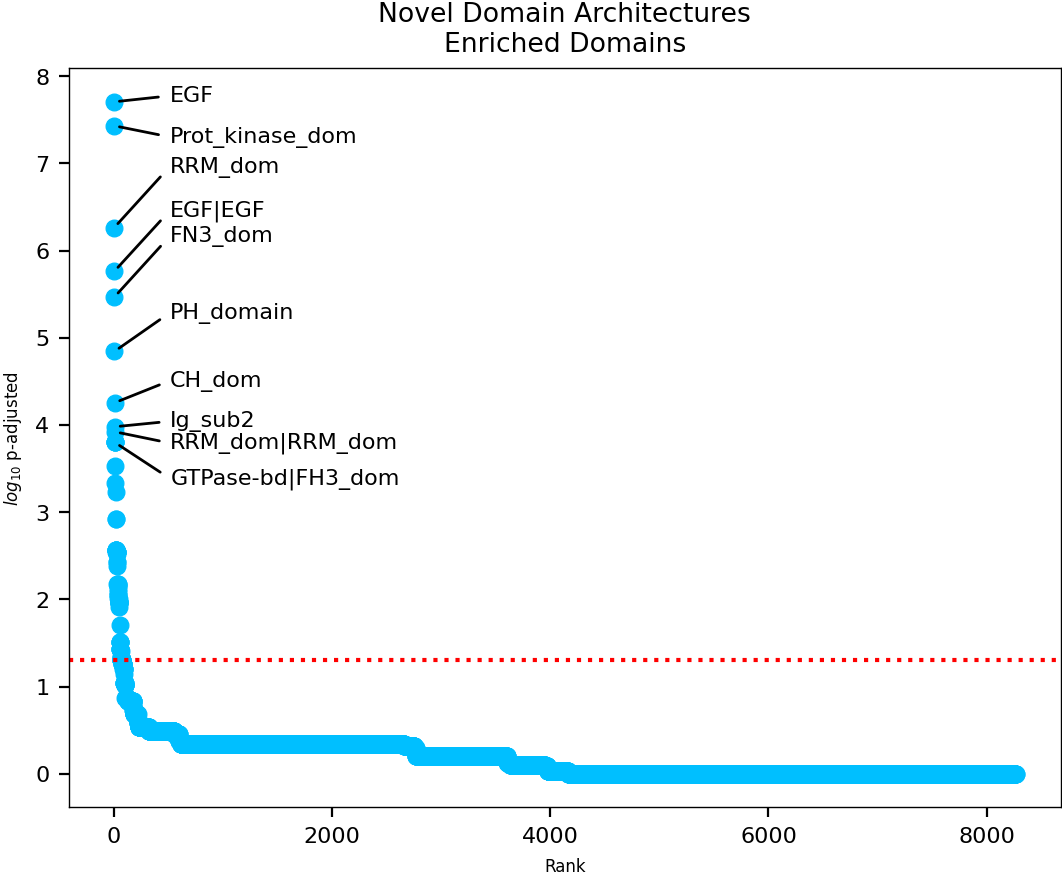

In [14]:
enrich_ccle_novel.plot(catOI = 'True')
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')
ax = plt.gca()
EnrichementAnalysis.add_top_ngram_annotations(ax, enrich_ccle_novel.res, proteome_net,cat='True',yoffset=[0,-6,20,20,20,12,6,0,-6,-15])
plt.title('Novel Domain Architectures\nEnriched Domains')

Now the TCGA equivalent where we get only the domain architectures per unique fusion protein.

In [15]:
tcga_dansy_res = pd.read_csv('TCGA_Fusion_DANSY_Summary.csv', index_col=0,na_values=None)
tcga_dansy_res.dropna(subset=['dansy_impact'], inplace=True)
tcga_dansy_res.domain_architecture.fillna('', inplace=True)

In [16]:
tcga_dansy_minimal = tcga_dansy_res.filter(['name','domain_architecture','dansy_impact']).drop_duplicates()
tcga_dansy_minimal['novel_arch'] = tcga_dansy_minimal.dansy_impact.apply(lambda x: str(x in ['Bridges', 'Reinforcement']))

# Get the n-grams to check for
tcga_ngrams = dansy.ngramUtilities.return_ngrams_from_list(tcga_dansy_minimal.domain_architecture,5)
tcga_ngrams_preexist = sorted(set(tcga_ngrams).intersection(nat_ngrams))

In [17]:
# Now perform both of the enrichment analyses based on the two different categories
tcga_dansy_enrich = EnrichementAnalysis.EnrichmentAnalysis(tcga_dansy_minimal, tcga_ngrams_preexist,
                                                           mapper = {'category':'dansy_impact',
                                                                     'domain_architecture':'domain_architecture'})
tcga_novel_enrich = EnrichementAnalysis.EnrichmentAnalysis(tcga_dansy_minimal, tcga_ngrams_preexist,
                                                           mapper = {'category':'novel_arch',
                                                                     'domain_architecture':'domain_architecture'})

100%|██████████| 11026/11026 [00:32<00:00, 344.28it/s]


Text(0.5, 1.0, 'Bridges\nDomain Enrichment')

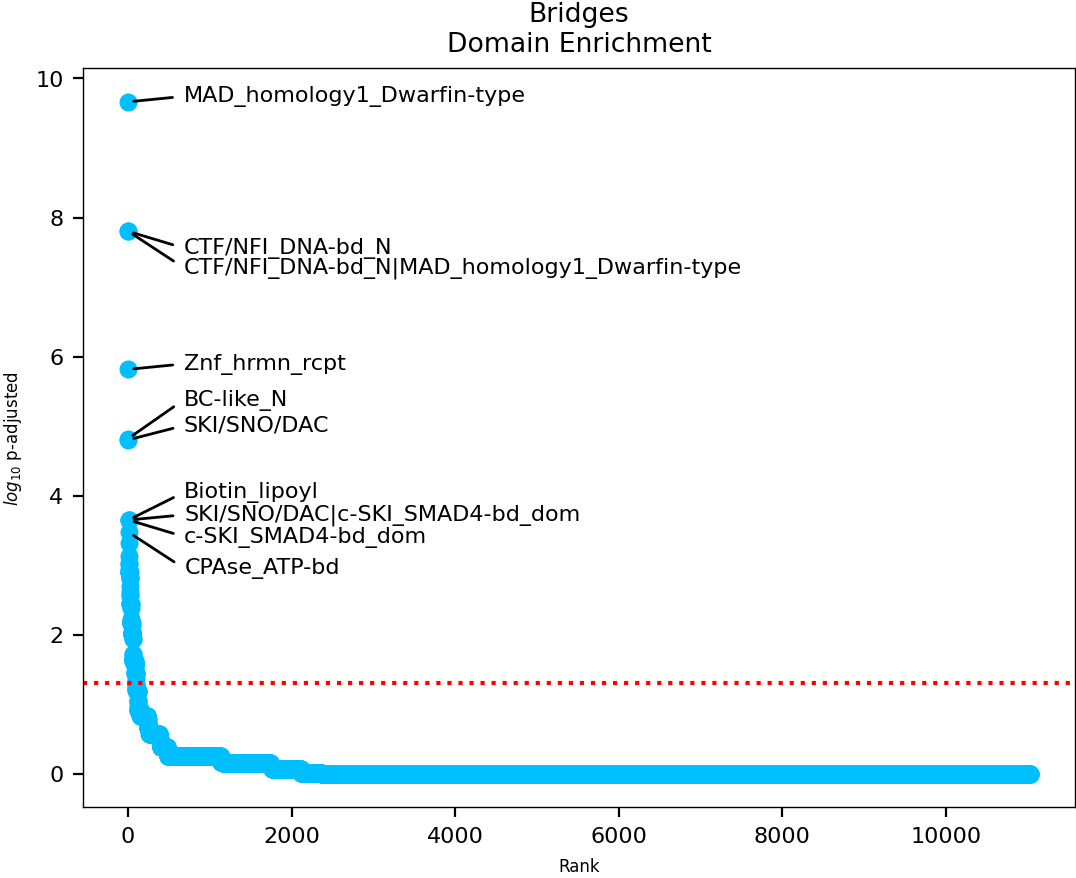

In [18]:
tcga_dansy_enrich.plot('Bridges')
ax = plt.gca()
n = min(sum(tcga_dansy_enrich.res.Bridges_q.le(0.05)),10)
EnrichementAnalysis.add_top_ngram_annotations(ax, tcga_dansy_enrich.res, proteome_net,cat=colOI,n=n,yoffset=[0,-8,-15,0,12,3,8,0,-8,-15])
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')
plt.title('Bridges\nDomain Enrichment')

Text(0.5, 1.0, 'Novel Domain Architectures\nDomain Enrichment')

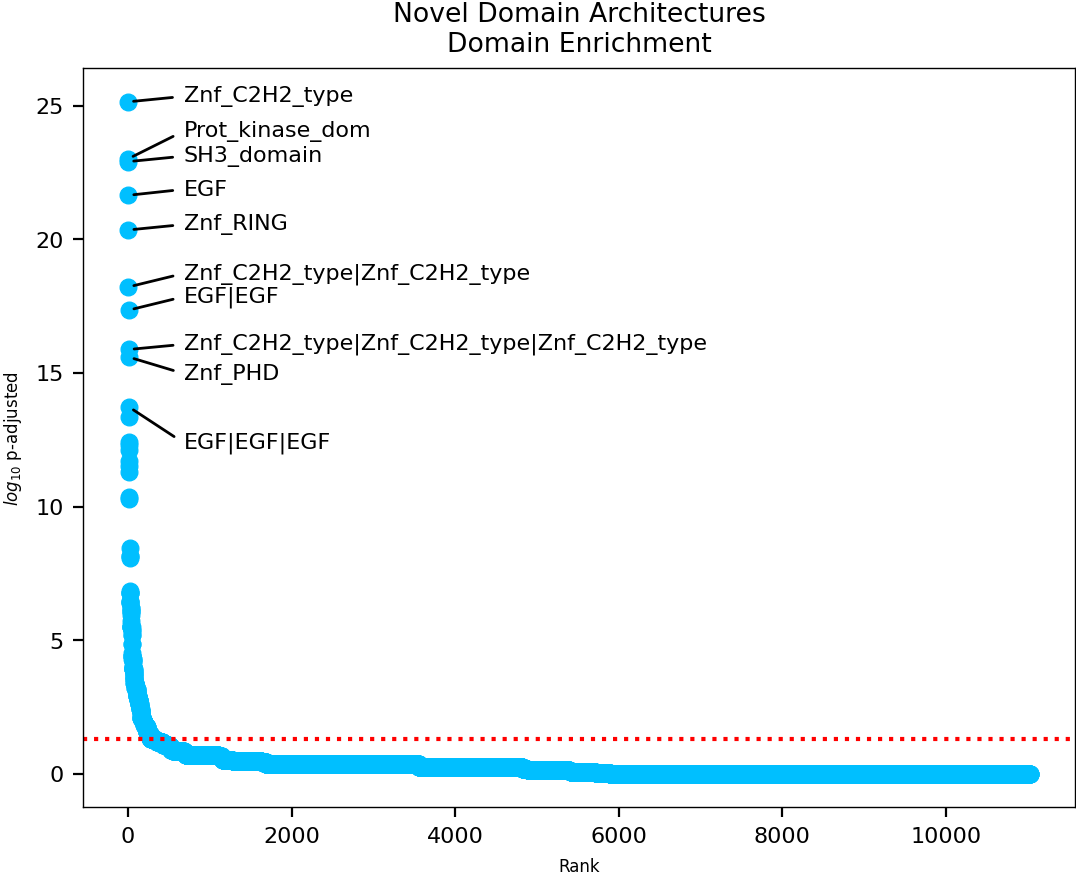

In [19]:
tcga_novel_enrich.plot('True')
ax = plt.gca()
n = min(sum(tcga_novel_enrich.res.True_q.le(0.05)),10)
EnrichementAnalysis.add_top_ngram_annotations(ax, tcga_novel_enrich.res, proteome_net,cat='True',n=n,yoffset=[0,8,0,0,0,3,3,0,-8,-15])
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')
plt.title('Novel Domain Architectures\nDomain Enrichment')

Now let's look at the recurrent (happening in more than one cancer type)

In [42]:
tcga_dansy_res.columns

Index(['name', 'h_gene', 't_gene', 'h_uniprot', 't_uniprot', 'h_chr', 't_chr',
       'h_pos', 't_pos', 'h_strand', 't_strand', 'id', 'domain_architecture',
       'BarcodeID', 'Cancertype', 'dansy_impact'],
      dtype='object')

In [59]:
tcga_grouped = tcga_dansy_res.groupby(['name','domain_architecture'])
recurrent_status = pd.Series(index = tcga_grouped.groups, dtype=str)
for group in tcga_grouped.groups:
    x = tcga_grouped.get_group(group)
    recurrent_status.loc[group] = str(len(x['Cancertype'].unique()) > 1)
recurrent_status = recurrent_status.to_frame().reset_index(names=['name','domain_architecture']).rename(columns={0:'Recurrent'})

In [60]:

tcga_recurrent_enrich = EnrichementAnalysis.EnrichmentAnalysis(recurrent_status, tcga_ngrams_preexist, mapper={'domain_architecture':'domain_architecture', 'category':'Recurrent'})

100%|██████████| 11026/11026 [00:32<00:00, 339.86it/s]


In [62]:
tcga_recurrent_enrich.res

,ngram,False,True,n,False_q,True_q
0,,1.000000,1.000000,15646.0,1.0,1.0
1,IPR000001,0.650013,1.000000,8.0,1.0,1.0
2,IPR000001|IPR000001,0.850859,1.000000,3.0,1.0,1.0
3,IPR000001|IPR000001|IPR000001,0.897924,1.000000,2.0,1.0,1.0
4,IPR000001|IPR000001|IPR000001|IPR001254,0.897924,1.000000,2.0,1.0,1.0
...,...,...,...,...,...,...
11021,IPR059154|IPR010598,0.947590,1.000000,1.0,1.0,1.0
11022,IPR059182,0.951672,0.314018,7.0,1.0,1.0
11023,IPR059238,0.947590,1.000000,1.0,1.0,1.0
11024,IPR059238|IPR001012,0.947590,1.000000,1.0,1.0,1.0


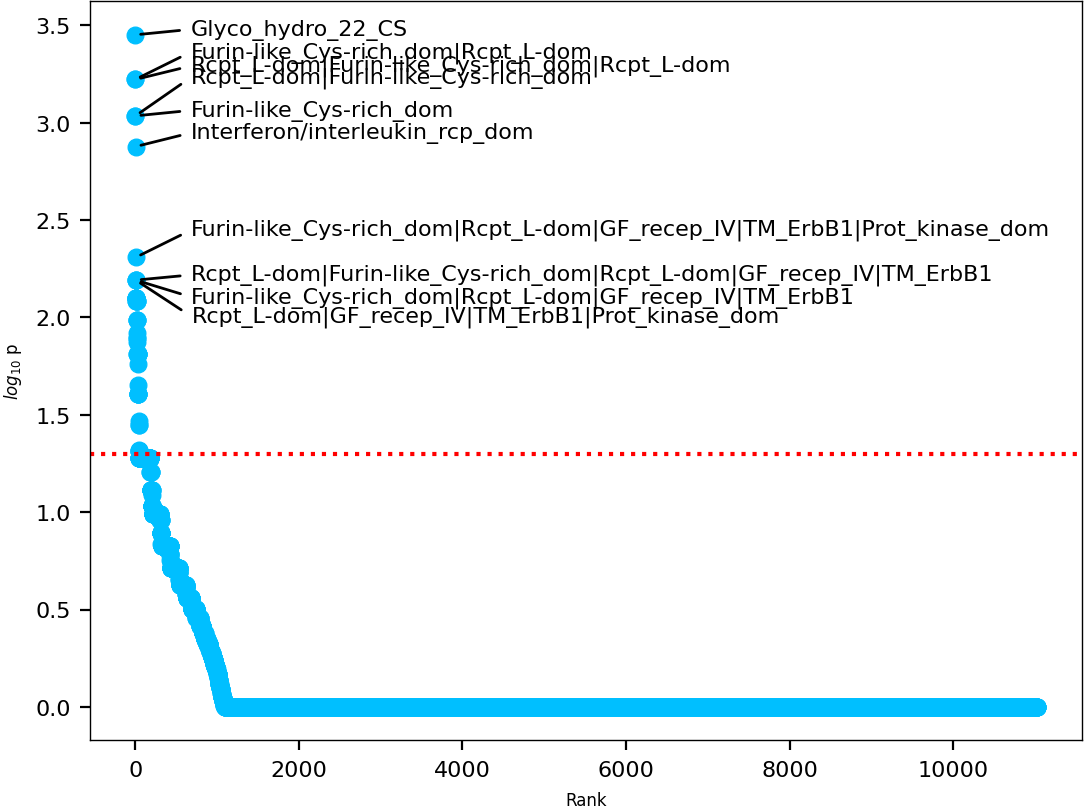

In [69]:
tcga_recurrent_enrich.plot('True', plot_adjusted = False)
ax = plt.gca()
n = min(sum(tcga_recurrent_enrich.res['True'].le(0.05)),10)
EnrichementAnalysis.add_top_ngram_annotations(ax, tcga_recurrent_enrich.res[tcga_recurrent_enrich.res['ngram'] != ''], proteome_net,cat='True',n=n,yoffset=[0,8,3,0,12,3,8,0,-8,-15], plot_adjusted=False)
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')

Now let's bring up the betweenness and degree centrality measurements to perform correlations with.

In [20]:
# Because some of the n-grams for the enriched analysis may have to do with collapsed n-grams making a new dansy object to get their values.
uncollapse_proteome = dansy.dansy(ref=ref_df, n=15, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [21]:
bcs = nx.betweenness_centrality(uncollapse_proteome.G, k = 3000, seed = 123) # Because of the size of the uncollapsed network, if we try to calculate the betweenness centrality of the entire network it will take quite a bit of time. So we can randomly choose a subset of nodes (in this case 3000) to use as sources for the shortest paths. This gets us a good approximate value that can be used for correlative analyses.
dcs = nx.degree_centrality(uncollapse_proteome.G)

In [22]:
reps = {}
for ngram in tcga_novel_enrich.res['ngram'][1:]:
    temp = uncollapse_proteome.retrieve_protein_info(ngram = ngram)
    reps[ngram] = len(temp)

In [23]:
tcga_res = tcga_novel_enrich.res.copy()
tcga_res['betweenness'] = tcga_res['ngram'].map(bcs)
tcga_res['degree'] = tcga_res['ngram'].map(dcs)
tcga_res['proteins'] = tcga_res['ngram'].map(reps)

In [24]:
tcga_res['True_q_log'] = tcga_res['True_q'].apply(lambda x: -1*np.log10(x))
tcga_res['betweenness_log'] = tcga_res.betweenness.apply(lambda x: np.log10(x+1))
tcga_res['proteins_log'] = tcga_res['proteins'].apply(lambda x: np.log10(x))

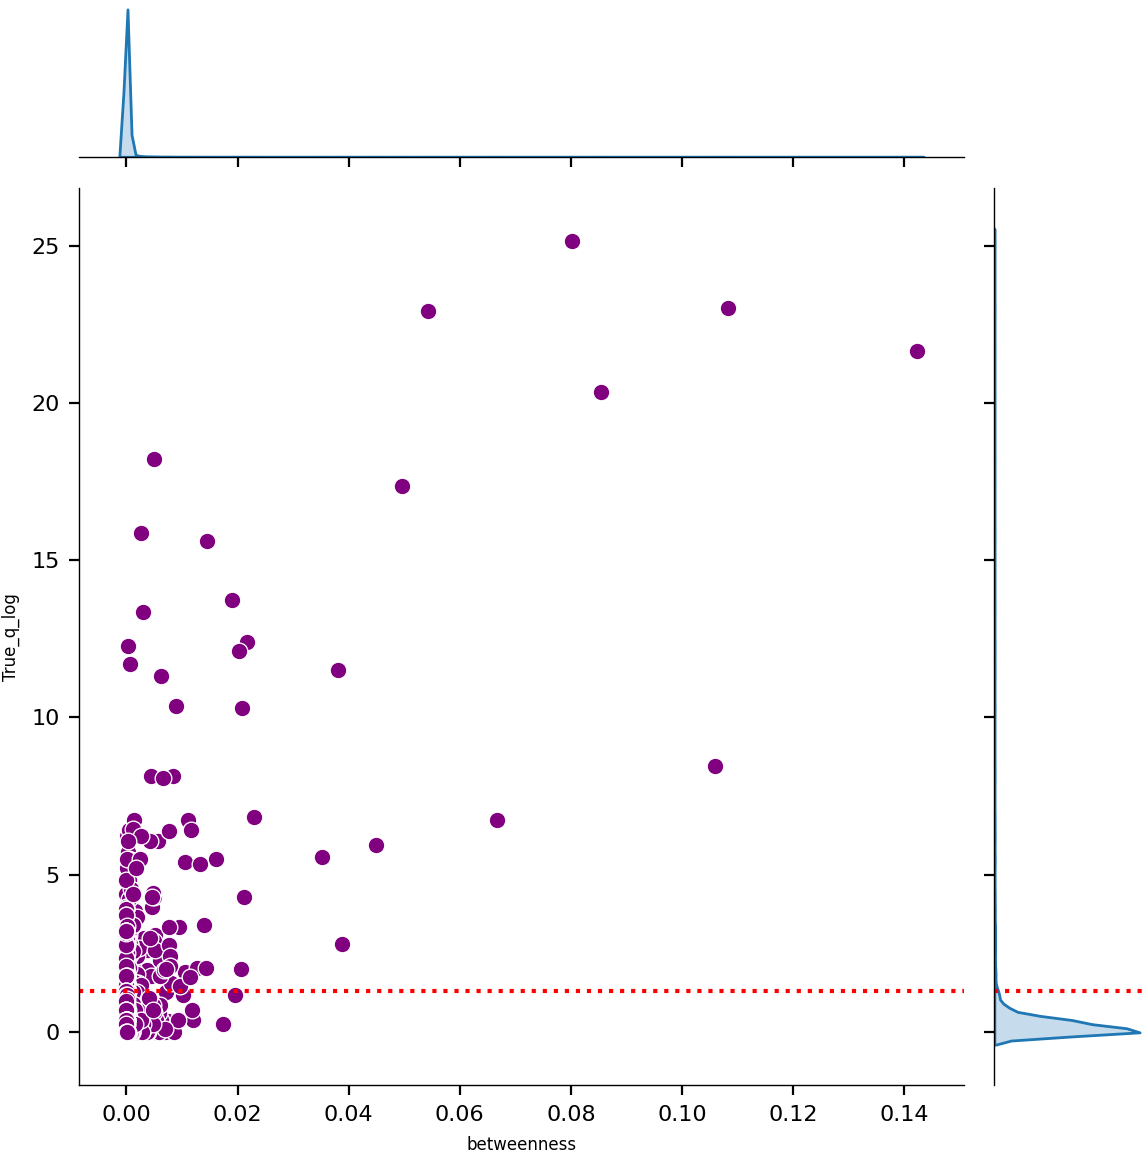

In [25]:
p = sns.JointGrid(tcga_res, x = 'betweenness', y='True_q_log')
p.plot_joint(sns.scatterplot, color='purple')
p.plot_marginals(sns.kdeplot, fill=True)

plt.xlabel('Betweenness Centrality')
plt.ylabel('p-adjusted')
p.refline(y=-1*np.log10(0.05), ls = ':', color = 'r')

plt.show()

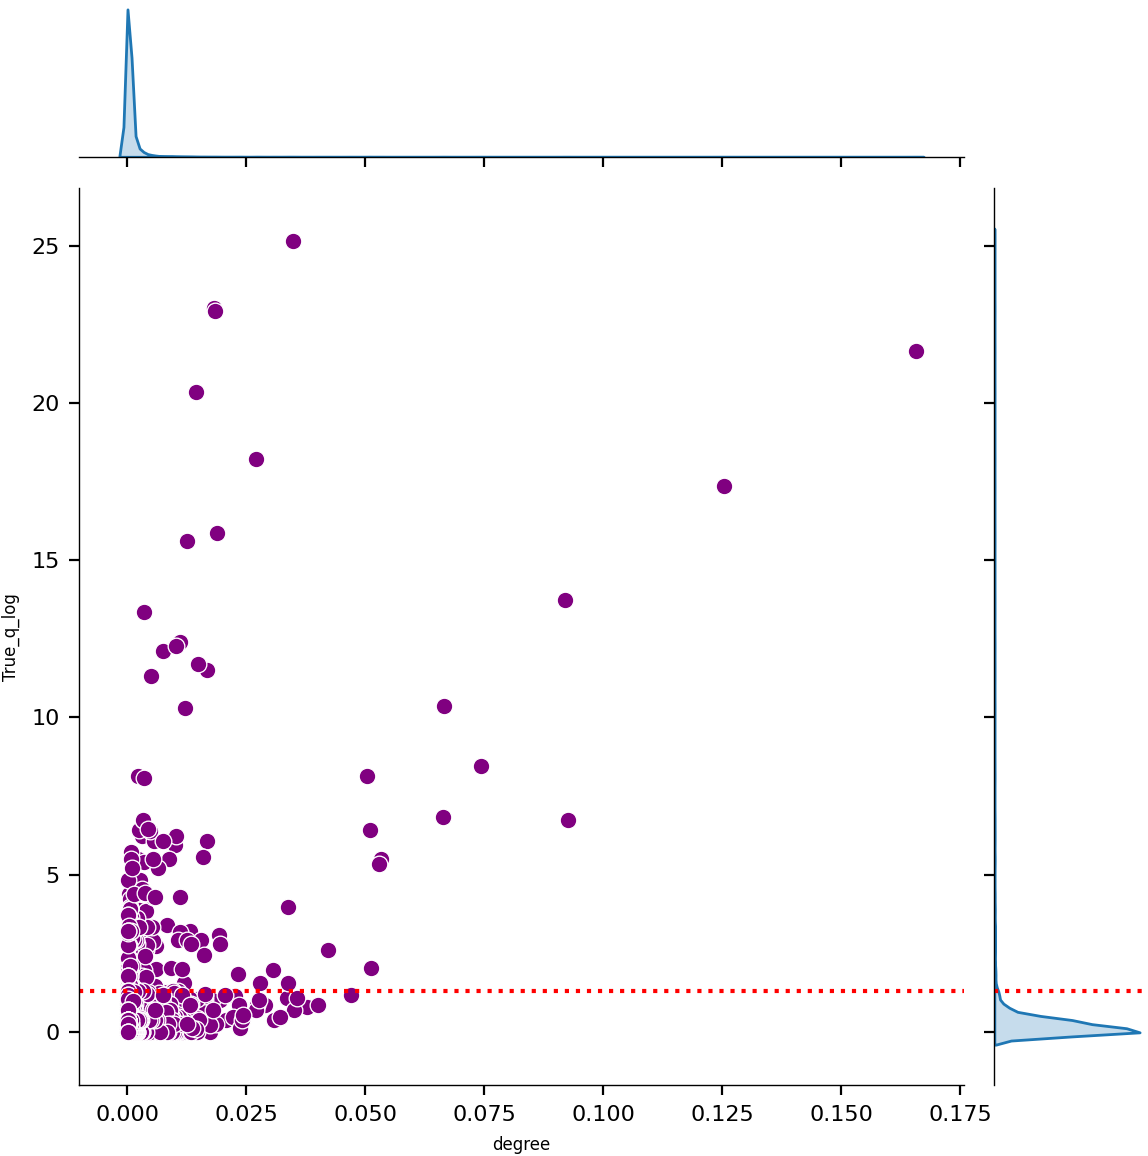

In [26]:
p = sns.JointGrid(tcga_res, x = 'degree', y='True_q_log')
p.plot_joint(sns.scatterplot, color='purple')
p.plot_marginals(sns.kdeplot, fill=True)
plt.xlabel('Betweenness Centrality')
plt.ylabel('p-adjusted')
p.refline(y=-1*np.log10(0.05), ls = ':', color = 'r')
plt.show()

To do some analysis of how different ranges of the betweenness/proteins/degree measurements relate to how significant a domain is enriched getting the percentile 

In [27]:
# Now doing the tertiles/quartiles of the betweenness centrality values to find the fraction/distribution of enrichment values
tcga_res['betweenness_quartile'] = pd.qcut(tcga_res['betweenness'], labels=['T1','T2','T3'],q = 3)
tcga_res['protein_quartile'] = pd.qcut(tcga_res['degree'], labels=['T1','T2','T3'],q = 3)

<Axes: xlabel='tertile', ylabel='value'>

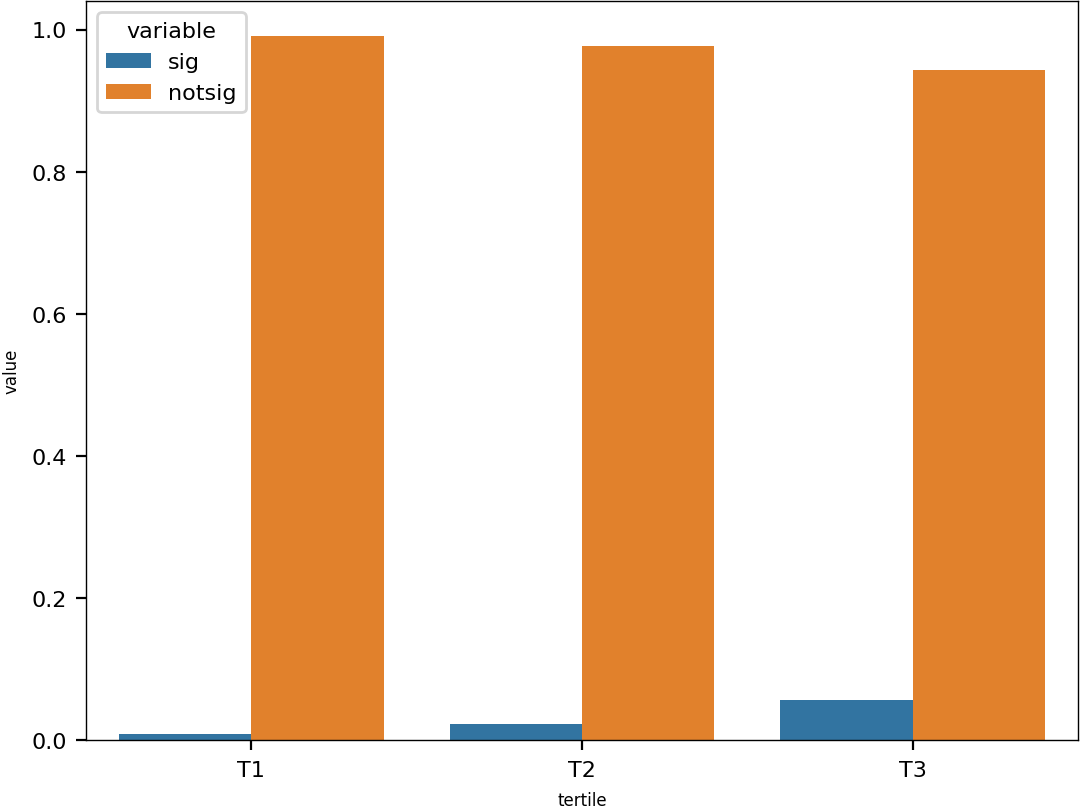

In [28]:
sumdata = tcga_res.filter(['True_q', 'betweenness_quartile']).dropna(subset='betweenness_quartile').groupby('betweenness_quartile', observed=True)
full_sum = pd.DataFrame(index = tcga_res.betweenness_quartile.unique().dropna(), columns = ['sig','notsig'])
for group in sumdata.groups:
    a = sumdata.get_group(group)
    full_sum.loc[group, 'sig'] = a.True_q.le(0.05).sum()/(len(a))
    full_sum.loc[group, 'notsig'] = a.True_q.ge(0.05).sum()/(len(a))
full_sum['tertile'] = full_sum.index
full_sum = full_sum.melt(id_vars='tertile')
sns.barplot(full_sum, x = 'tertile', y = 'value', hue = 'variable')

<Axes: xlabel='tertile', ylabel='value'>

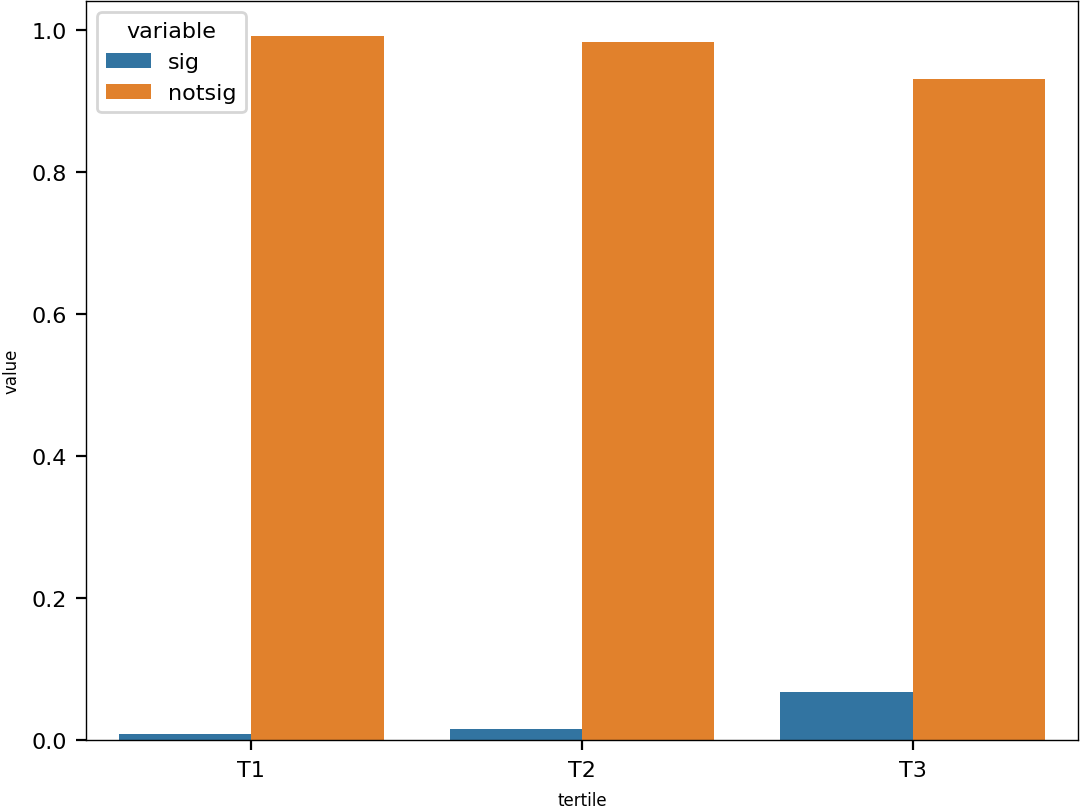

In [29]:
sumdata = tcga_res.filter(['True_q', 'protein_quartile']).dropna(subset='protein_quartile').groupby('protein_quartile', observed=True)
full_sum = pd.DataFrame(index = tcga_res.protein_quartile.unique().dropna(), columns = ['sig','notsig'])
for group in sumdata.groups:
    a = sumdata.get_group(group)
    full_sum.loc[group, 'sig'] = a.True_q.le(0.05).sum()/(len(a))
    full_sum.loc[group, 'notsig'] = a.True_q.ge(0.05).sum()/(len(a))
full_sum['tertile'] = full_sum.index
full_sum = full_sum.melt(id_vars='tertile')
sns.barplot(full_sum, x = 'tertile', y = 'value', hue = 'variable')

Domain "de-enrichment" analysis

In [30]:
# To make it a little easier to find those with dropped domains, I will first grab all the uniprot IDs and get the crontributions overall and compare those to the full length protein.
ids_4_analysis = []
for i,f in ccle_fc.fusion_list.items():
    if 't_contribution' in f.__dict__ and 'h_contribution' in f.__dict__:
        # Now check if there are domain annotations for both parent proteins otherwise won't add
        h_arch = proteome_net.retrieve_protein_info(prot = f.h_uniprot)['Interpro Domain Architecture IDs'].values[0]
        t_arch = proteome_net.retrieve_protein_info(prot = f.t_uniprot)['Interpro Domain Architecture IDs'].values[0]
        if h_arch != '' or t_arch != '': # Ignore the fusions that consist of only proteins with no domain annotations.
            ids_4_analysis.append(i)


In [31]:
deenrich_fusion_dansy = ccle_full_dansy[ccle_full_dansy.id.isin(ids_4_analysis)].copy()

In [32]:
# Now let's append the dropped domains onto the dataframe as another column that can then be unstacked for enrichment analysis
deenrich_fusion_dansy['dropped_domains'] = deenrich_fusion_dansy['id'].apply(lambda x: [ccle_fc.get_fusion(x).h_contribution, ccle_fc.get_fusion(x).t_contribution])
deenrich_fusion_dansy = deenrich_fusion_dansy.explode('dropped_domains')

# Now let's remove the no annotation strings cause they only clutter up the analysis
deenrich_fusion_dansy = deenrich_fusion_dansy[deenrich_fusion_dansy['dropped_domains'] != '']

In [33]:
# Now let's simply the dataframe to be only the most important information and to remove duplicate information that complicates the analysis.
deenrich_data = deenrich_fusion_dansy.filter(['fusion_protein_name', 'dansy_impact', 'dropped_domains']).drop_duplicates()
deenrich_data['novel_arch'] = deenrich_data['dansy_impact'].apply(lambda x: str(x in ['Bridges','Reinforcement']))

In [34]:
# Now get only the n-grams in these to focus those within the dropped domains
deenrich_ngrams = dansy.ngramUtilities.return_ngrams_from_list(deenrich_data.dropped_domains,5)

In [35]:
deenrich_dansy_focus = EnrichementAnalysis.EnrichmentAnalysis(deenrich_data, deenrich_ngrams,{'category':'dansy_impact','domain_architecture':'dropped_domains'})

100%|██████████| 8174/8174 [00:14<00:00, 561.02it/s]


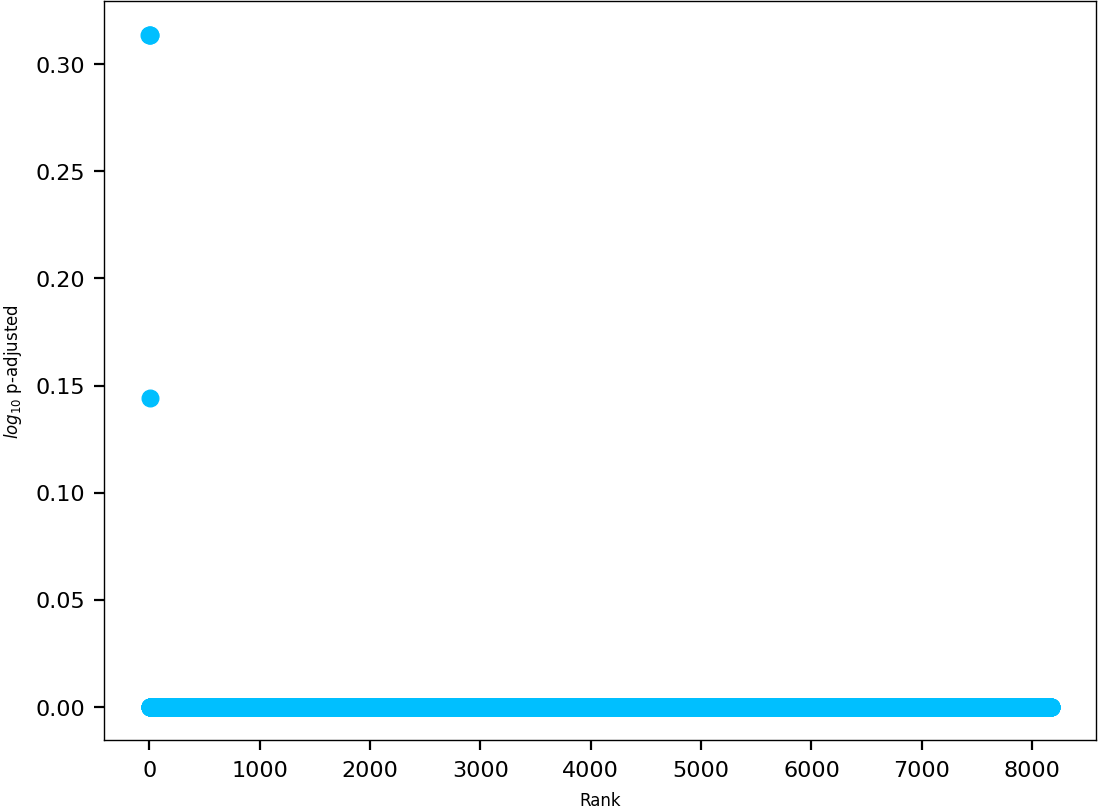

In [36]:
deenrich_dansy_focus.plot('No Change')

In [37]:
deenrich_novel_focus = EnrichementAnalysis.EnrichmentAnalysis(deenrich_data, deenrich_ngrams,{'category':'novel_arch','domain_architecture':'dropped_domains'})

100%|██████████| 8174/8174 [00:13<00:00, 622.02it/s]


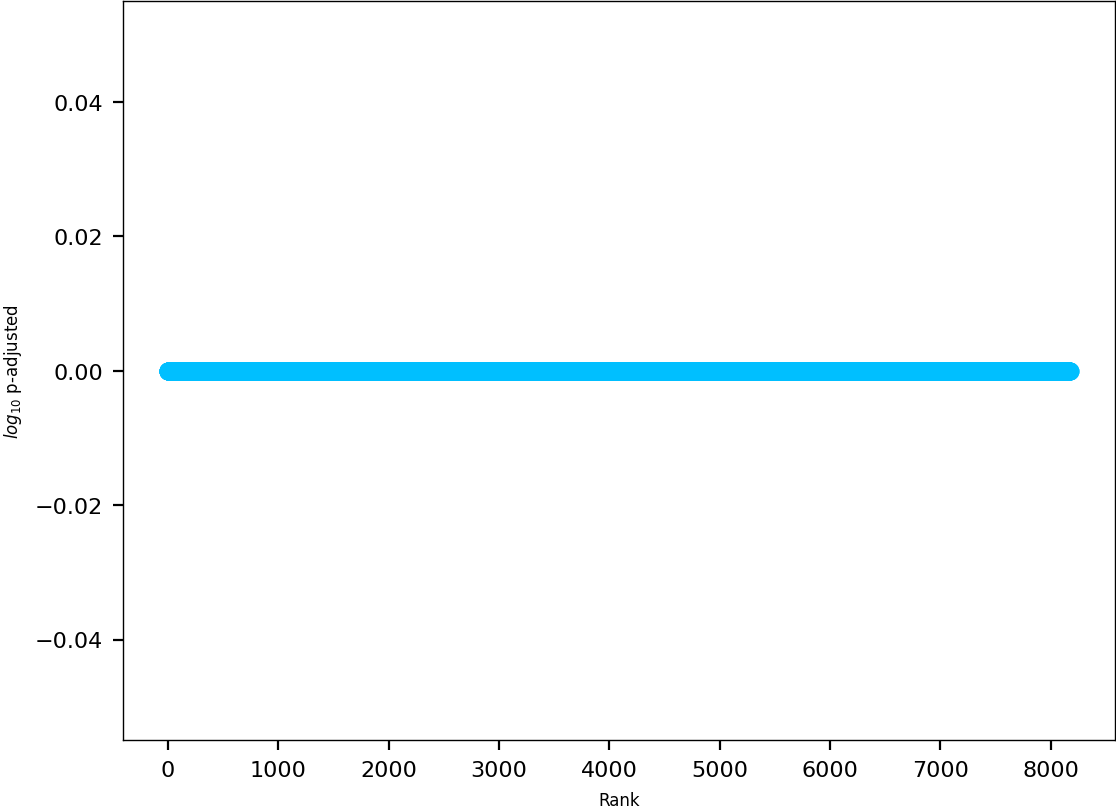

In [38]:
deenrich_novel_focus.plot('True')

Bringing in the essentiality scores now

In [80]:
# Importing the dependency results
dep_res = pd.read_csv('Fusion_dependency_results.csv', index_col=0)
dep_res.dropna(subset=['domain_architecture', 'MDDS'], inplace=True)

# Now let's clean up the dependency scores to focus on unique domain architectures of specific proteins and if they present specific dependencies
dependency_filtered = dep_res.filter(['fusion_protein', 'domain_architecture', 'potential_dependence']).drop_duplicates()
dependency_filtered['potential_dependence'] = dependency_filtered['potential_dependence'].astype(str)

In [74]:
# Check the domain architecture n-grams to then check for enrichment of.
dep_ngrams = dansy.ngramUtilities.return_ngrams_from_list(dependency_filtered.domain_architecture, 5)
dep_ngrams_preexist = sorted(set(dep_ngrams).intersection(nat_ngrams))

In [81]:
# Now perform the enrichment analysis.
dep_enrich = EnrichementAnalysis.EnrichmentAnalysis(dependency_filtered, dep_ngrams_preexist, {'domain_architecture':'domain_architecture',
                                                                                               'category':'potential_dependence'})

100%|██████████| 6687/6687 [00:07<00:00, 878.32it/s] 


In [82]:
dep_enrich.res

,ngram,True,False,n,True_q,False_q
0,IPR000001,1.000000,0.886262,4.0,1.0,1.0
1,IPR000001|IPR000001,1.000000,0.913436,3.0,1.0,1.0
2,IPR000001|IPR000001|IPR001254,1.000000,0.913436,3.0,1.0,1.0
3,IPR000001|IPR000719,1.000000,0.970280,1.0,1.0,1.0
4,IPR000001|IPR001254,1.000000,0.913436,3.0,1.0,1.0
...,...,...,...,...,...,...
6682,IPR059117|IPR025980,1.000000,0.970280,1.0,1.0,1.0
6683,IPR059117|IPR025980|IPR024951,1.000000,0.970280,1.0,1.0,1.0
6684,IPR059154,1.000000,0.941434,2.0,1.0,1.0
6685,IPR059154|IPR010598,1.000000,0.941434,2.0,1.0,1.0


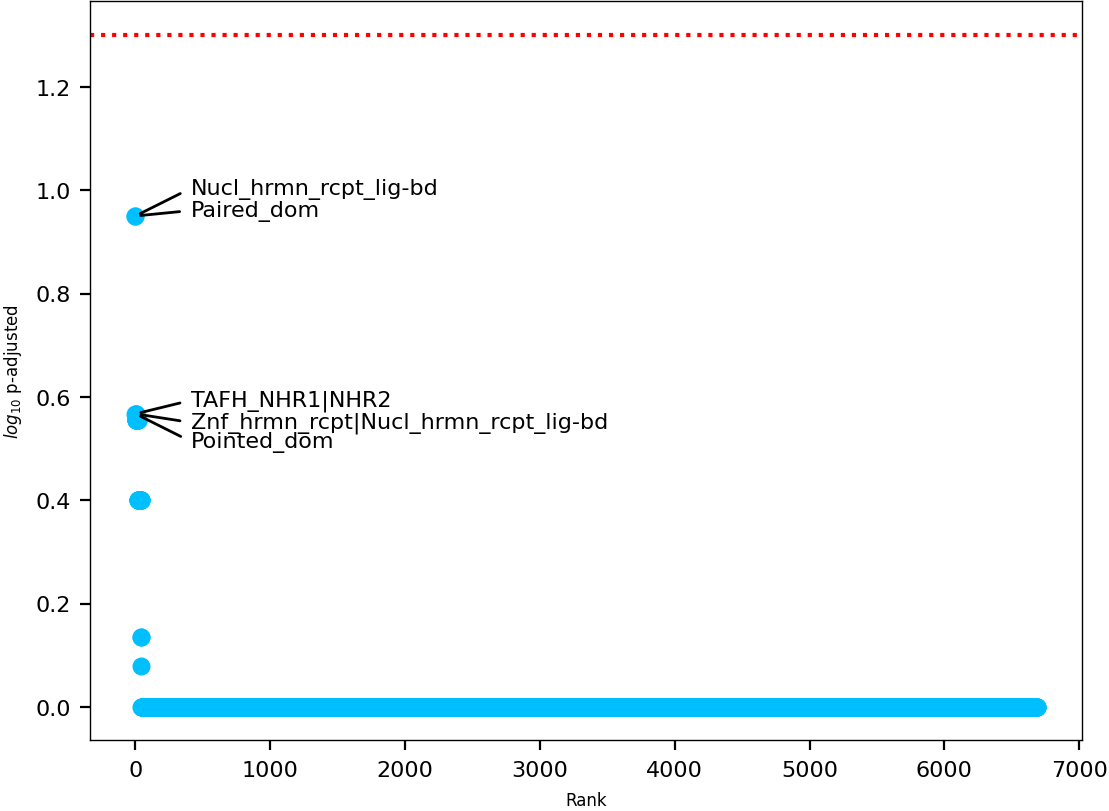

In [88]:
dep_enrich.plot('True')
ax = plt.gca()
n = min(sum(dep_enrich.res['True'].le(0.05)),5)
EnrichementAnalysis.add_top_ngram_annotations(ax, dep_enrich.res, proteome_net,cat='True',n=n,yoffset=[0,8,3,-5,-12,3,8,0,-8,-15])
plt.axhline(-1*np.log10(0.05), ls = ':', color = 'r')